In [8]:
import glob
import os

import pandas as pd
import numpy as np

import torch
from model import LightningWAttention
import two_fold_train
import losses

from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

import mplhep as hep
hep.style.use("ATLAS")

In [9]:
fold  = "fold0"
ckpt_files = glob.glob(f"./hww_pctransformer_kfold/{fold}/version_0/checkpoints/*.ckpt")
print(f"Found checkpoint files: {ckpt_files}")
if not ckpt_files: 
    raise FileNotFoundError(f"No checkpoint files found in checkpoints")
ckpt_path = ckpt_files[0]  # Use the first checkpoint found
print(f"Using checkpoint: {ckpt_path}")

Found checkpoint files: []


FileNotFoundError: No checkpoint files found in checkpoints

In [ ]:
# Retrieve datamodule used in training
train = two_fold_train
dm = train.main(train=False)
# Load model from checkpoint
model = LightningWAttention.load_from_checkpoint(ckpt_path, weights_only=False, strict=False)
model.eval() # used to inference -> not for training phase

# Set up the data module (prepare data and setup splits)
dm.setup(stage="test")  # Ensure test dataset is ready
# Get the test dataloader
test_loader = dm.test_dataloader()

# Run inference
train_features = np.zeros([0, dm.X.shape[1]])
predictions = np.zeros([0, dm.Y.shape[1]-2]) # without including W0 and W1 mass
true_labels = np.zeros([0, dm.Y.shape[1]])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

n = 0
with torch.no_grad():  # Disable gradient computation for inference
    for batch in test_loader:
        # Assuming batch contains inputs and targets
        inputs, targets = batch
        # print(f"Inputs shape: {inputs.shape}, Targets shape: {targets.shape}")
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        # Forward pass
        outputs, swap_outputs = model(inputs)
        higgs_mass = losses.higgs_mass_loss(outputs.cpu())
        mae = losses.mae_loss(outputs.cpu(), targets.cpu())
        std_losses = higgs_mass + mae
        swap_higgs_mass = losses.higgs_mass_loss(swap_outputs.cpu())
        swap_mae = losses.mae_loss(swap_outputs.cpu(), targets.cpu())
        swap_losses = swap_higgs_mass + swap_mae
        
        use_swap = torch.unsqueeze(swap_losses < std_losses, dim=-1).cpu()
        print("Swap losses:", swap_losses.cpu().numpy(), "Standard losses:", std_losses.cpu().numpy())
        outputs = torch.where(use_swap, swap_outputs.cpu(), outputs.cpu())
        print("Swap evts:", use_swap.sum().item(), "Total evts:", len(use_swap), "Swap fraction:", use_swap.sum().item() / len(use_swap))
            
        # Store predictions and true labels
        train_features = np.append(train_features, inputs.cpu().numpy(), axis=0)
        predictions = np.append(predictions, outputs.cpu().numpy(), axis=0)
        true_labels = np.append(true_labels, targets.cpu().numpy(), axis=0)
    print(f"Total samples: {len(predictions)}, Swapped samples: {n}")

Evaluation mode, loading checkpoints...
Training objects shape: (376985, 26)
Target objects shape: (376985, 10)
Removed 0 rows with NaN or infinite values
Loading model from checkpoint for evaluation.
Using 4 num of workers in data loading.
Setting up testing data module...
Using explicit (KFold) dataset split
Swap losses: [25.271563 25.27933  26.146456 25.119226 27.33056  25.958452 26.247149
 25.153757 26.902346 25.766626 25.658846 25.60612  25.590906 25.140284
 29.415956 25.717783 26.069803 25.196344 25.334597 25.589914 26.117044
 25.423555 26.167154 25.932444 26.141977 25.54999  25.652094 26.418924
 26.910097 25.348269 25.330904 27.251993 25.442934 26.613512 25.772882
 25.725153 25.49586  25.14245  25.536905 25.655    25.409456 25.678446
 25.426134 25.271639 26.18159  25.850473 26.994898 25.614084 25.722391
 26.307947 25.246988 25.61767  25.160387 25.182306 27.403238 26.673082
 25.555681 25.297602 25.76636  25.436213 25.135012 25.291094 25.325167
 25.748941 25.305529 25.15259  25.12

In [ ]:
true_lep0_px = train_features[:, 0]
true_lep0_py = train_features[:, 1]
true_lep0_pz = train_features[:, 2]
true_lep0_energy = train_features[:, 3]
true_lep1_px = train_features[:, 4]
true_lep1_py = train_features[:, 5]
true_lep1_pz = train_features[:, 6]
true_lep1_energy = train_features[:, 7]

In [ ]:
pred_w0_px = predictions[..., 0]
pred_w0_py = predictions[..., 1]
pred_w0_pz = predictions[..., 2]
pred_w0_energy = predictions[..., 3]
pred_w1_px = predictions[..., 4]
pred_w1_py = predictions[..., 5]
pred_w1_pz = predictions[..., 6]
pred_w1_energy = predictions[..., 7]
pred_w0_mass_2 = pred_w0_energy**2 - (pred_w0_px**2 + pred_w0_py**2 + pred_w0_pz**2)
pred_w1_mass_2 = pred_w1_energy**2 - (pred_w1_px**2 + pred_w1_py**2 + pred_w1_pz**2)

true_w0_px = true_labels[..., 0]
true_w0_py = true_labels[..., 1]
true_w0_pz = true_labels[..., 2]
true_w0_energy = true_labels[..., 3]
true_w1_px = true_labels[..., 4]
true_w1_py = true_labels[..., 5]
true_w1_pz = true_labels[..., 6]
true_w1_energy = true_labels[..., 7]
true_w0_mass_2 = true_labels[..., 8] ** 2
true_w1_mass_2 = true_labels[..., 9] ** 2

In [ ]:
def rel_err_func(a, b):
    if  np.isnan(a).any() or np.isnan(b).any():
        print("Warning: NaN values detected in input arrays.")
    if (np.any(b == 0)):
        print("Warning: Zero values detected in denominator array.")
    mask = ~np.isnan(a) & ~np.isnan(b) & (b != 0)
    return (a[mask] - b[mask]) / b[mask]


In [ ]:
def err_bounds(x, rel_err=0.2, offset=5.0):
    delta = rel_err * np.abs(x) + offset
    upper = x + delta
    lower = x - delta
    return upper, lower

In [ ]:
def rmse(a, b):
    if  np.isnan(a).any() or np.isnan(b).any():
        print("Warning: NaN values detected in input arrays.")
    if (np.any(b == 0)):
        print("Warning: Zero values detected in denominator array.")
    mask = ~np.isnan(a) & ~np.isnan(b) & (b != 0)
    return np.sqrt(np.mean((a[mask] - b[mask]) ** 2))

In [ ]:
def plot_1d_hist(pred, truth, name, bins_edges=np.linspace(-200, 200, 51), unit="GeV", color="black", savepath=None):
    plt.hist(pred, bins=bins_edges, linewidth=2, color="red", histtype="step", label="Pred")
    plt.hist(truth, bins=bins_edges, linewidth=2, color="blue", histtype="step", label="True")
    plt.legend()
    plt.xlabel(unit, loc="right")
    plt.ylabel("Events", loc="top")
    plt.title(name, loc="right")
    
    txt = hep.atlas.label("Internal Simulation", data=True, loc=2, rlabel="")
    txt[0].set_color(color)
    txt[1].set_color(color)
    plt.tick_params(axis="both", which="major", pad=10)
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()
def plot_2d_hist(pred, truth, name, bins_edges=np.linspace(-200, 200, 51), log=False, unit="GeV", color="black", vmax=1e2, offset=0.0, savepath=None):
    err = 0.2
    cor_mask = np.abs(rel_err_func(pred, truth)) <= err # set 20% relative error cut
    if log:
        norm = LogNorm(vmin=1, vmax=vmax)
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", norm=norm)
    else:
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", vmin=1, vmax=vmax)
        
    # Plot error guides aligned with bin edges
    upper, lower = err_bounds(bins_edges, rel_err=err, offset=offset)
    plt.plot(upper, bins_edges, color="gainsboro", linestyle="-", label=r"$\pm 20\% offset$")
    plt.plot(bins_edges, bins_edges, color="gainsboro", linestyle="--")
    plt.plot(lower, bins_edges, color="gainsboro", linestyle="-")
    
    plt.xlabel(f"Pred [{unit}]")
    plt.ylabel(f"True [{unit}]")
    plt.title(f"{name}"+f" with RMSE: {rmse(pred, truth):.2f}", loc="right")
    print(f"Rel err < 20%: {100*np.sum(cor_mask)/len(truth):.2f} %")
    
    txt = hep.atlas.label("Internal Simulation", data=True, loc=2, rlabel="")
    txt[0].set_color(color)
    txt[1].set_color(color)
    plt.tick_params(axis="both", which="major", pad=10) 
    plt.colorbar(label="Events")
    plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()

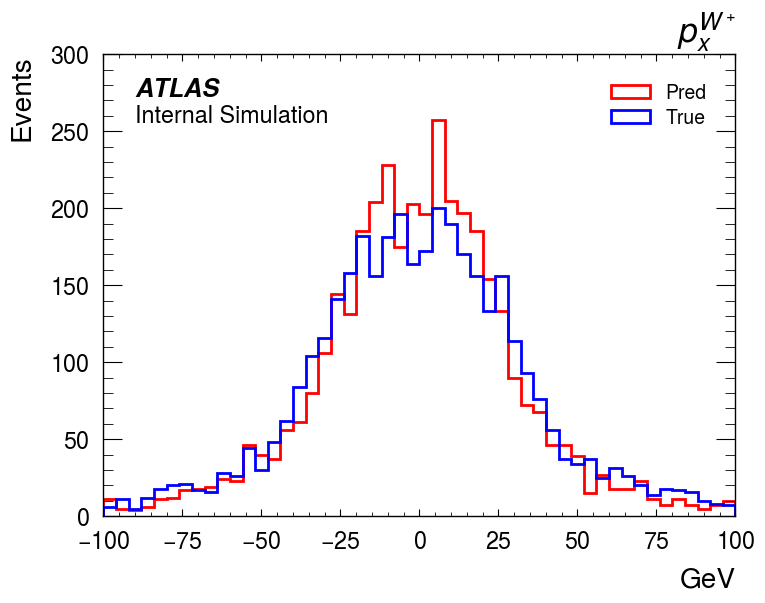

Rel err < 20%: 25.25 %


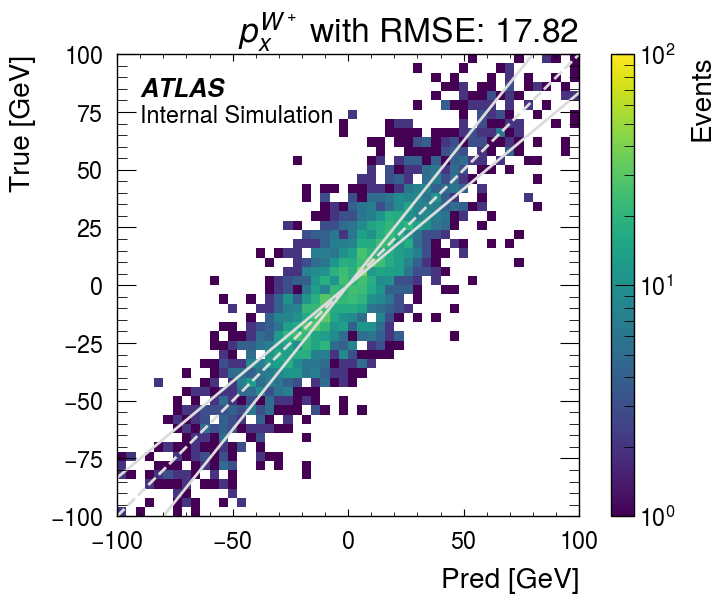

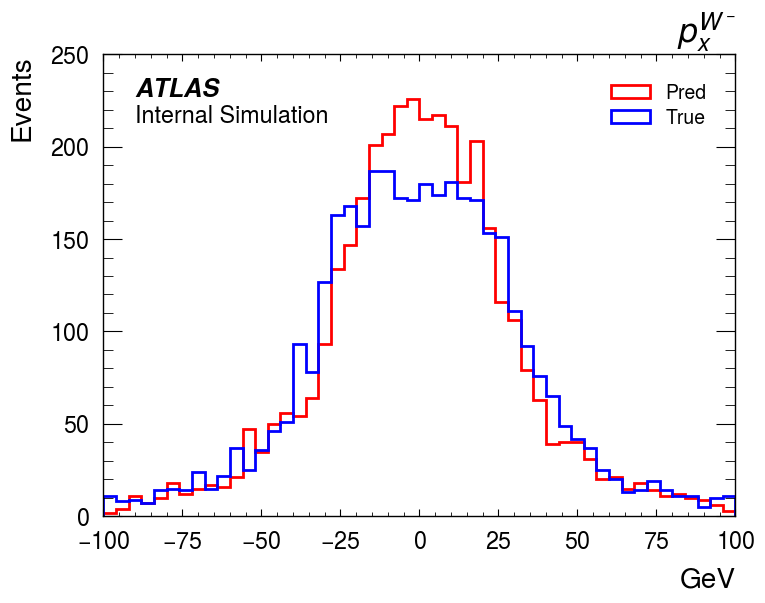

Rel err < 20%: 24.56 %


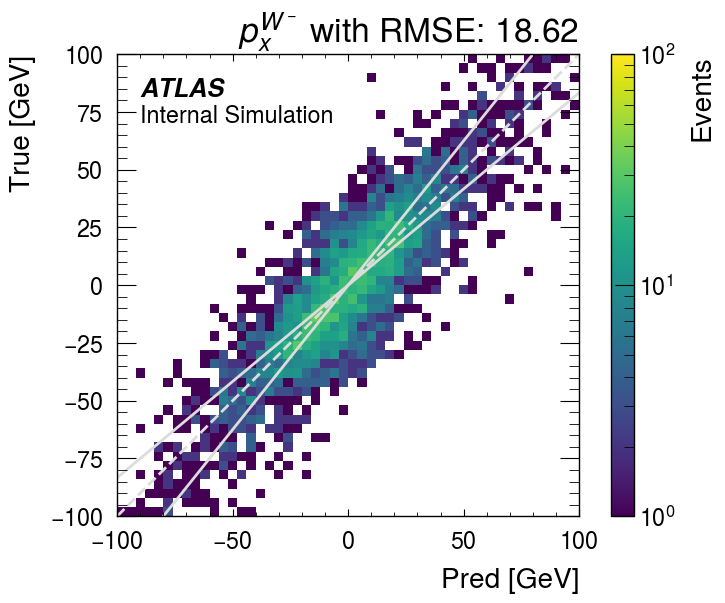

In [ ]:
bins = np.linspace(-100, 100, 51)
plot_1d_hist(pred_w0_px, true_w0_px, bins_edges=bins, name=r"$p_x^{W^+}$")
plot_2d_hist(pred_w0_px, true_w0_px, name=r"$p_x^{W^+}$", bins_edges=bins, log=True)
plot_1d_hist(pred_w1_px, true_w1_px, bins_edges=bins, name=r"$p_x^{W^-}$")
plot_2d_hist(pred_w1_px, true_w1_px, name=r"$p_x^{W^-}$", bins_edges=bins, log=True)

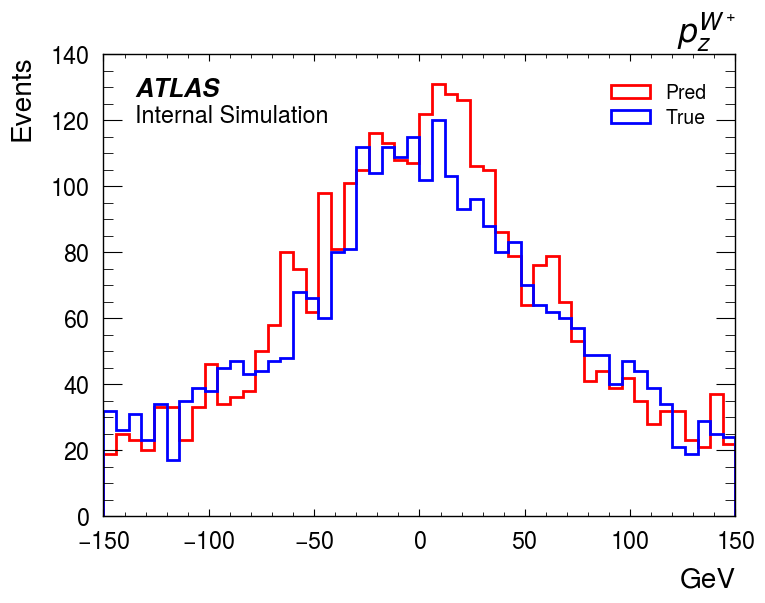

Rel err < 20%: 30.29 %


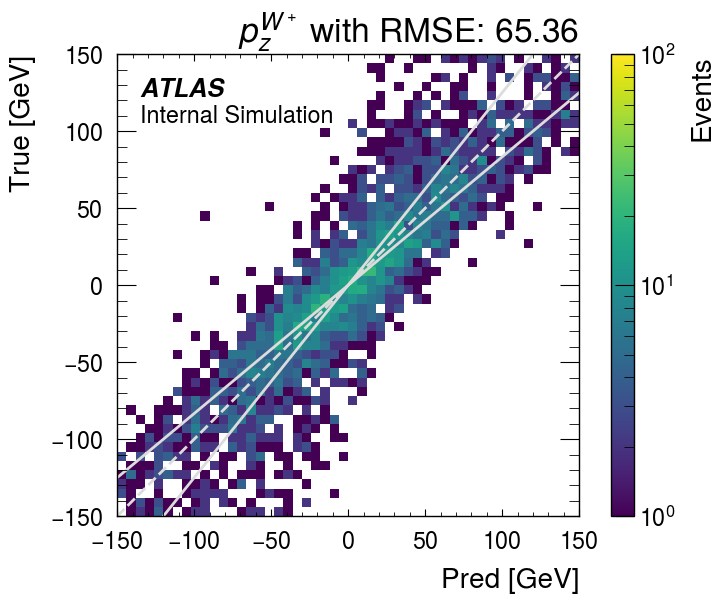

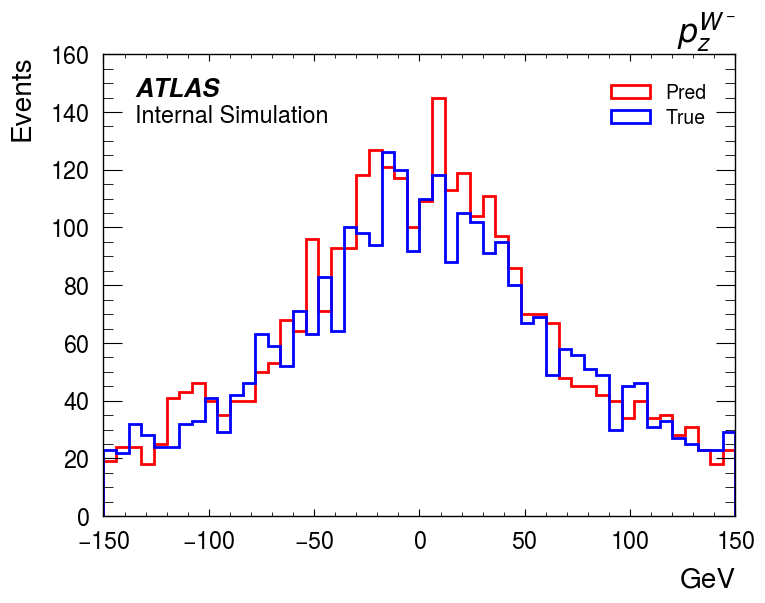

Rel err < 20%: 29.81 %


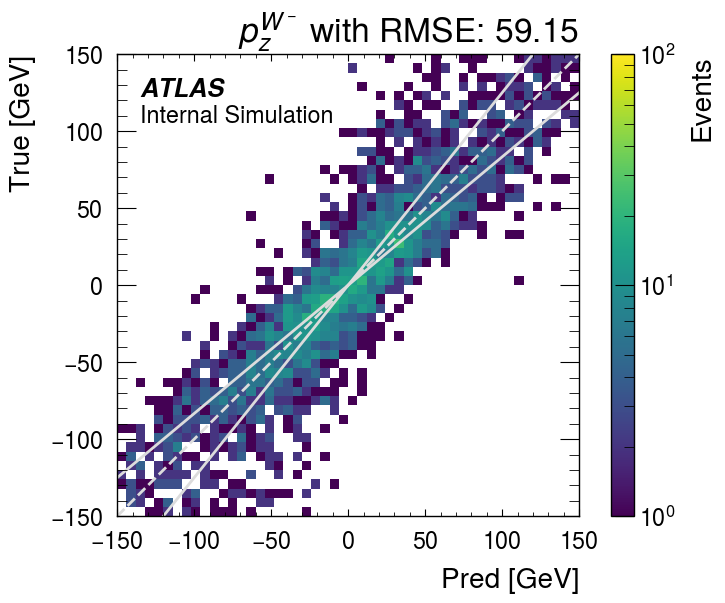

In [ ]:
bins = np.linspace(-150, 150, 51)
plot_1d_hist(pred_w0_pz, true_w0_pz, bins_edges=bins, name=r"$p_z^{W^+}$")
plot_2d_hist(pred_w0_pz, true_w0_pz, name=r"$p_z^{W^+}$", bins_edges=bins, log=True)
plot_1d_hist(pred_w1_pz, true_w1_pz, bins_edges=bins, name=r"$p_z^{W^-}$")
plot_2d_hist(pred_w1_pz, true_w1_pz, name=r"$p_z^{W^-}$", bins_edges=bins, log=True)

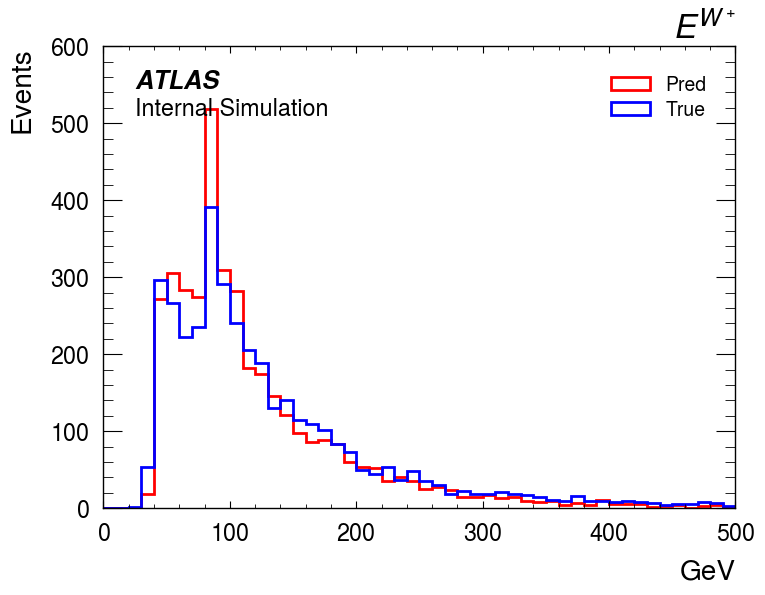

Rel err < 20%: 59.76 %


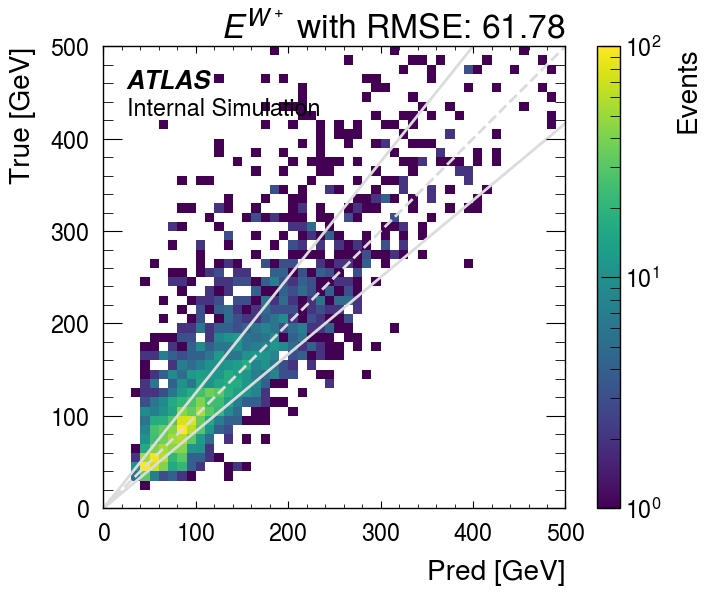

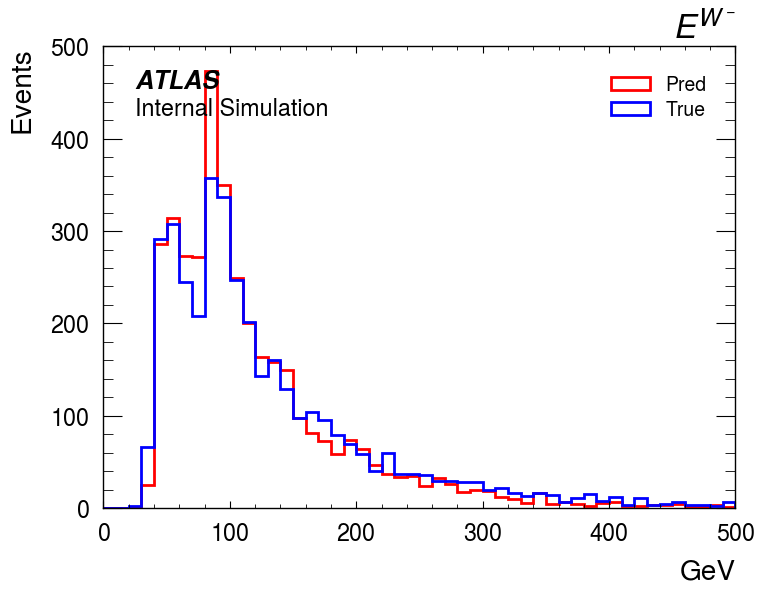

Rel err < 20%: 58.67 %


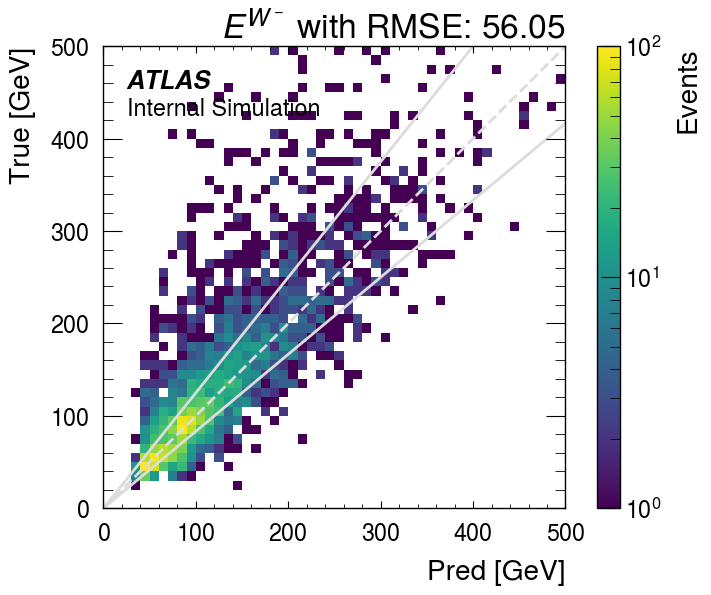

In [ ]:
bins = np.linspace(0, 500, 51)
plot_1d_hist(pred_w0_energy, true_w0_energy, bins_edges=bins, name=r"$E^{W^+}$")
plot_2d_hist(pred_w0_energy, true_w0_energy, name=r"$E^{W^+}$", bins_edges=bins, log=True, color="black")
plot_1d_hist(pred_w1_energy, true_w1_energy, bins_edges=bins, name=r"$E^{W^-}$")
plot_2d_hist(pred_w1_energy, true_w1_energy, name=r"$E^{W^-}$", bins_edges=bins, log=True, color="black")

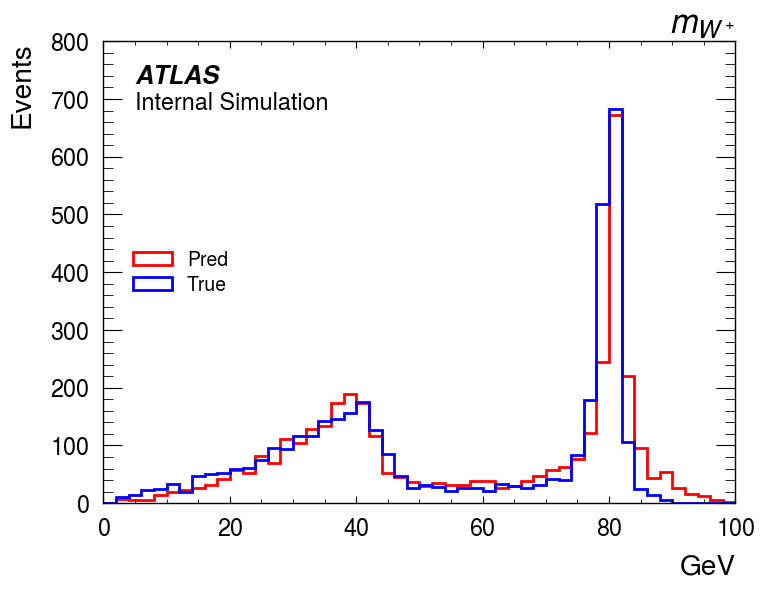

Rel err < 20%: 56.05 %


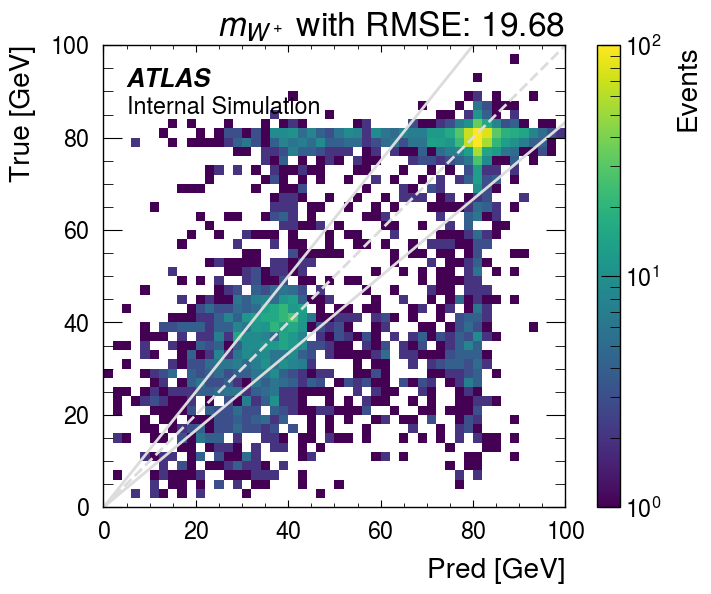

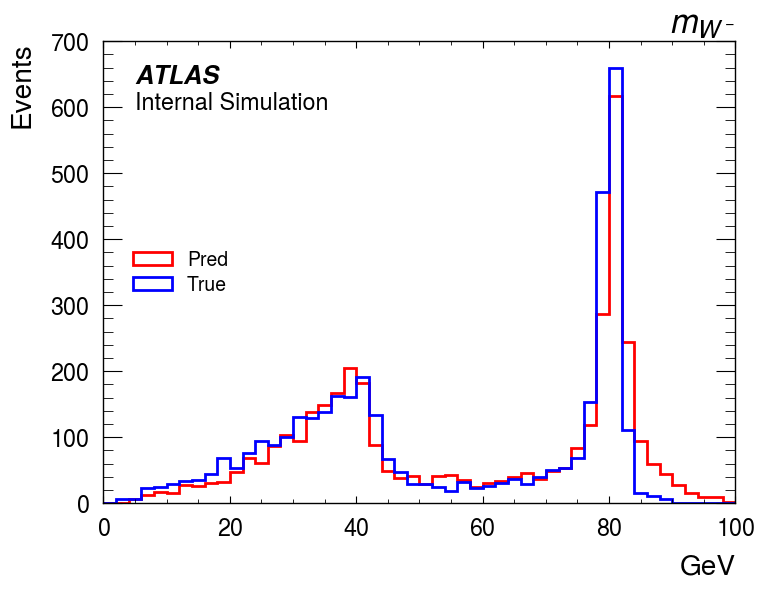

Rel err < 20%: 55.89 %


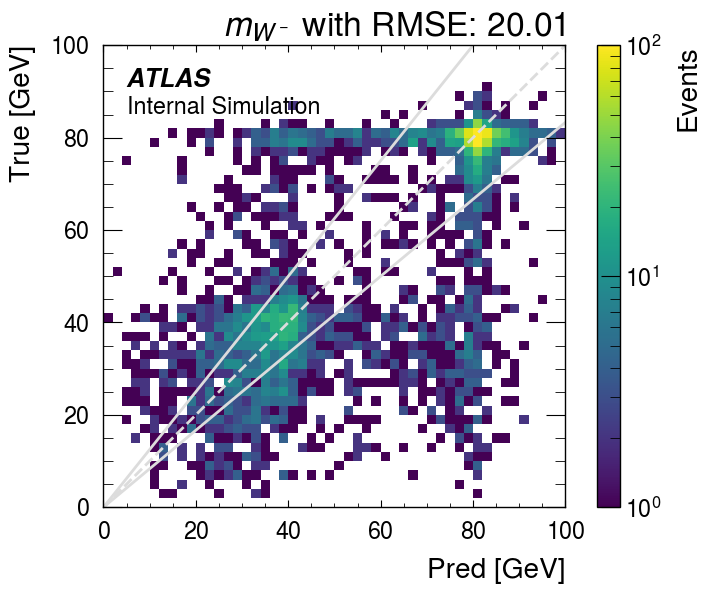

In [ ]:
bins = np.linspace(0, 100, 51)
plot_1d_hist(np.sqrt(pred_w0_mass_2), np.sqrt(true_w0_mass_2), bins_edges=bins, name=r"$m_{W^+}$", unit="GeV")
plot_2d_hist(np.sqrt(pred_w0_mass_2), np.sqrt(true_w0_mass_2), name=r"$m_{W^+}$", bins_edges=bins, log=True, unit="GeV")
plot_1d_hist(np.sqrt(pred_w1_mass_2), np.sqrt(true_w1_mass_2), bins_edges=bins, name=r"$m_{W^-}$", unit="GeV")
plot_2d_hist(np.sqrt(pred_w1_mass_2), np.sqrt(true_w1_mass_2), name=r"$m_{W^-}$", bins_edges=bins, log=True, unit="GeV")

In [ ]:
def plot_2d_res_hist(pred, truth, name_pos, name_neg, bins_edges=np.linspace(-200, 200, 51), log=False, unit="GeV", color="black", vmax=5e3, savepath=None):
    if log:
        norm = LogNorm(vmin=1, vmax=vmax)
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", norm=norm)
    else:
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", vmin=1, vmax=vmax)
    plt.xlabel(rf"$\Delta_\text{{res}}${name_pos} [{unit}]")
    plt.ylabel(rf"$\Delta_\text{{res}}${name_neg} [{unit}]")
    # plt.title(rf"{title}", loc="right")
    txt = hep.atlas.label("Internal Simulation", data=True, loc=0, rlabel="")
    txt[0].set_color(color)
    txt[1].set_color(color)
    plt.tick_params(axis="both", which="major", pad=10) 
    plt.colorbar(label="Events")
    plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()

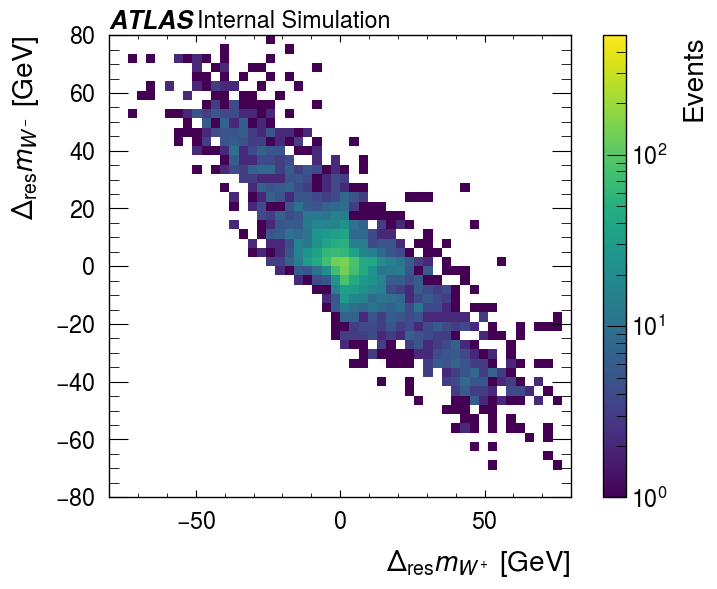

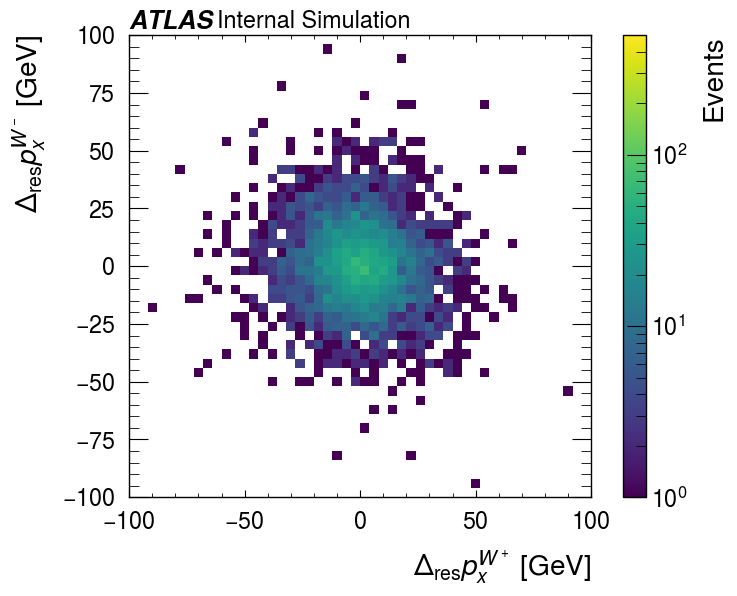

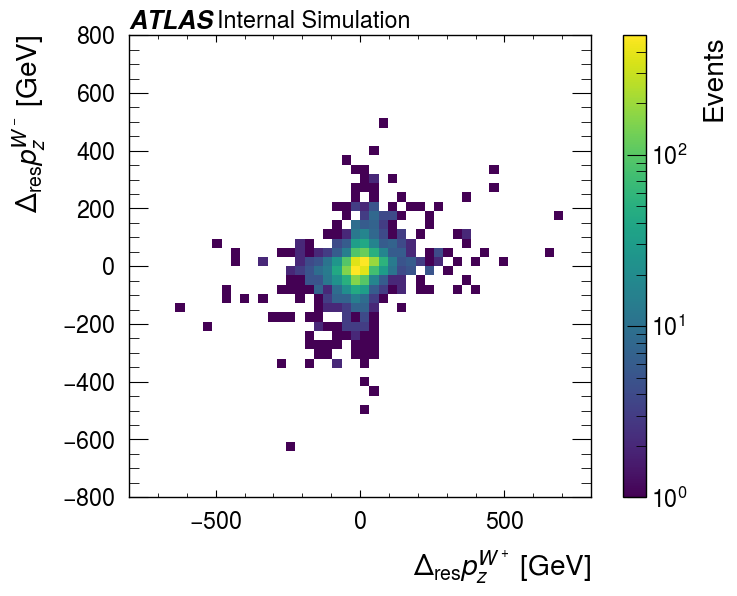

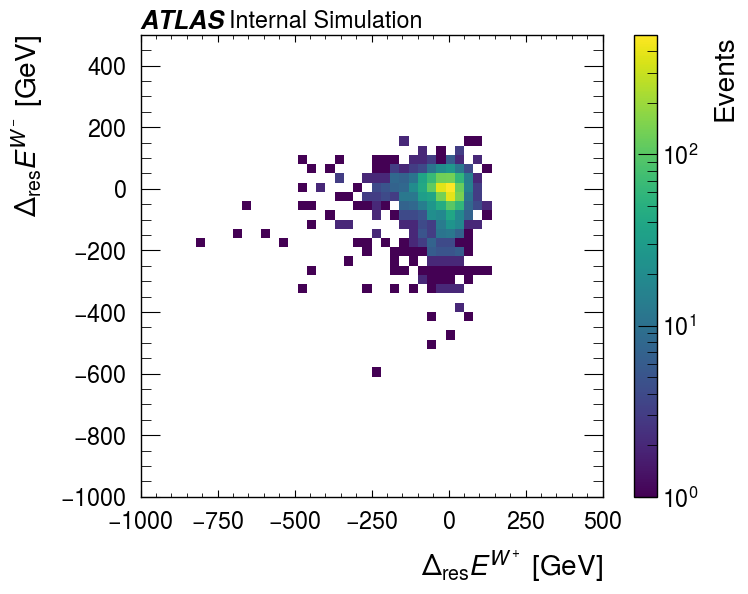

In [ ]:
w0_mass_res = np.sqrt(pred_w0_mass_2) - np.sqrt(true_w0_mass_2)
w1_res = np.sqrt(pred_w1_mass_2) - np.sqrt(true_w1_mass_2)
plot_2d_res_hist(w0_mass_res, w1_res, name_pos=r"$m_{W^+}$", name_neg=r"$m_{W^-}$", bins_edges=np.linspace(-80, 80, 51), log=True, unit="GeV", color="black", vmax=5e2)

w0_px_res = pred_w0_px - true_w0_px
w1_px_res = pred_w1_px - true_w1_px
plot_2d_res_hist(w0_px_res, w1_px_res, name_pos=r"$p_x^{W^+}$", name_neg=r"$p_x^{W^-}$", bins_edges=np.linspace(-100, 100, 51), log=True, unit="GeV", color="black", vmax=5e2)

w0_pz_res = pred_w0_pz - true_w0_pz
w1_pz_res = pred_w1_pz - true_w1_pz
plot_2d_res_hist(w0_pz_res, w1_pz_res, name_pos=r"$p_z^{W^+}$", name_neg=r"$p_z^{W^-}$", bins_edges=np.linspace(-800, 800, 51), log=True, unit="GeV", color="black", vmax=5e2)

w0_energy_res = pred_w0_energy - true_w0_energy
w1_energy_res = pred_w1_energy - true_w1_energy
plot_2d_res_hist(w0_energy_res, w1_energy_res, name_pos=r"$E^{W^+}$", name_neg=r"$E^{W^-}$", bins_edges=np.linspace(-1000, 500, 51), log=True, unit="GeV", color="black", vmax=5e2)

In [ ]:

def alpha_func(lep_on_p4, neu_on_p4, lep_off_p4, neu_off_p4):
    
    def _cal_mass(p4):
        return np.sqrt(p4[:, 3]**2 - p4[:, 0]**2 - p4[:, 1]**2 - p4[:, 2]**2)
    
    def _cal_norm(p4):
        return np.sqrt(p4[:, 0]**2 + p4[:, 1]**2 + p4[:, 2]**2)
    
    # dinu_p4 = neu_on_p4 + neu_off_p4
    # dinu_mass = _cal_mass(dinu_p4)
    dinu_lep_on_p4 = lep_on_p4 + neu_on_p4 + neu_off_p4
    dinu_lep_on_mass = _cal_mass(dinu_lep_on_p4)
    dinu_lep_off_p4 = lep_off_p4 + neu_on_p4 + neu_off_p4
    dinu_lep_off_mass = _cal_mass(dinu_lep_off_p4)
        
    alpha = np.where(
        dinu_lep_on_mass > dinu_lep_off_mass,
        _cal_norm(neu_on_p4) / (_cal_norm(neu_on_p4) + _cal_norm(neu_off_p4) + 1e-16),
        _cal_norm(neu_off_p4) / (_cal_norm(neu_on_p4) + _cal_norm(neu_off_p4) + 1e-16)
    )
    
    return alpha

# true
true_w0_p4 = np.stack([true_w0_px, true_w0_py, true_w0_pz, true_w0_energy], axis=-1)
true_w1_p4 = np.stack([true_w1_px, true_w1_py, true_w1_pz, true_w1_energy], axis=-1)
true_lep0_p4 = np.stack([true_lep0_px, true_lep0_py, true_lep0_pz, true_lep0_energy], axis=-1)
true_lep1_p4 = np.stack([true_lep1_px, true_lep1_py, true_lep1_pz, true_lep1_energy], axis=-1)

# pred
pred_w0_p4 = np.stack([pred_w0_px, pred_w0_py, pred_w0_pz, pred_w0_energy], axis=-1)
pred_w1_p4 = np.stack([pred_w1_px, pred_w1_py, pred_w1_pz, pred_w1_energy], axis=-1)

w_mass_con = 80.379 # GeV
w_mass_con_2 = w_mass_con ** 2

true_0_on_mask = np.abs(true_w0_mass_2 - w_mass_con_2) < np.abs(true_w1_mass_2 - w_mass_con_2)
true_lep_on_p4 = np.where(true_0_on_mask[:, np.newaxis], true_lep0_p4, true_lep1_p4)
true_lep_off_p4 = np.where(true_0_on_mask[:, np.newaxis], true_lep1_p4, true_lep0_p4)
true_w_on_p4 = np.where(true_0_on_mask[:, np.newaxis], true_w0_p4, true_w1_p4)
true_w_off_p4 = np.where(true_0_on_mask[:, np.newaxis], true_w1_p4, true_w0_p4)
true_neu_on_p4 = true_w_on_p4 - true_lep_on_p4
true_neu_off_p4 = true_w_off_p4 - true_lep_off_p4

pred_0_on_mask = np.abs(pred_w0_mass_2 - w_mass_con_2) < np.abs(pred_w1_mass_2 - w_mass_con_2)
pred_w_on_p4 = np.where(pred_0_on_mask[:, np.newaxis], pred_w0_p4, pred_w1_p4)
pred_w_off_p4 = np.where(pred_0_on_mask[:, np.newaxis], pred_w1_p4, pred_w0_p4)
pred_neu_on_p4 = pred_w_on_p4 - true_lep_on_p4
pred_neu_off_p4 = pred_w_off_p4 - true_lep_off_p4

true_alpha = alpha_func(true_lep_on_p4, true_neu_on_p4, true_lep_off_p4, true_neu_off_p4)
pred_alpha = alpha_func(true_lep_on_p4, pred_neu_on_p4, true_lep_off_p4, pred_neu_off_p4)

/tmp/ipykernel_189833/2923680903.py:4: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(p4[:, 3]**2 - p4[:, 0]**2 - p4[:, 1]**2 - p4[:, 2]**2)


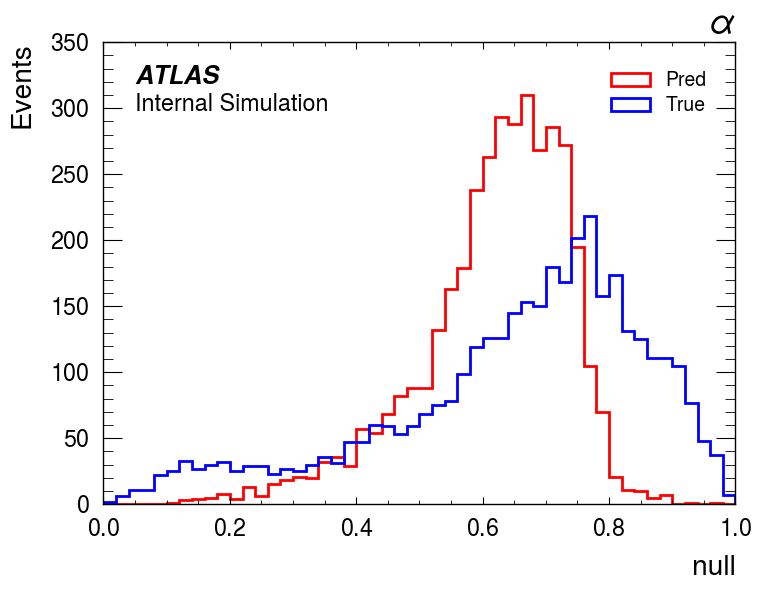

l+ alpha RMSE: 0.21414084948623632
Rel err < 20%: 50.77 %


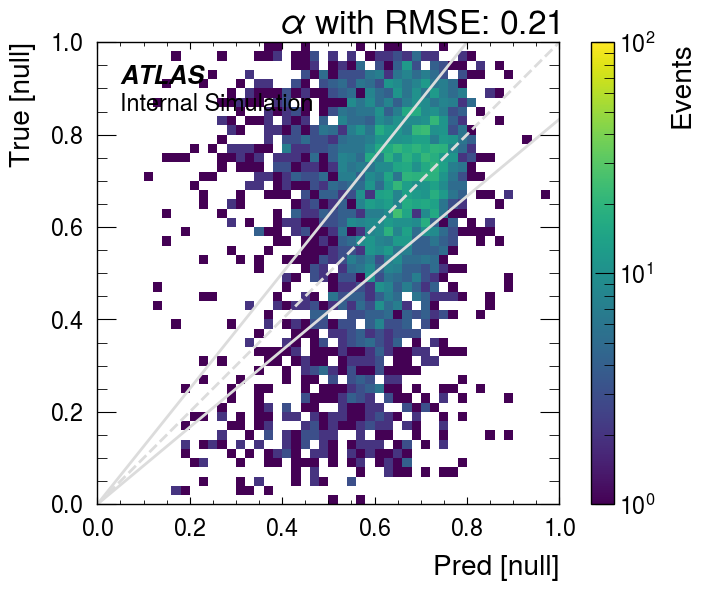

In [ ]:
plot_1d_hist(pred_alpha, true_alpha, r"$\alpha$", np.linspace(0, 1, 51), unit="null")
print("l+ alpha RMSE:", rmse(pred_alpha, true_alpha))
plot_2d_hist(pred_alpha, true_alpha, r"$\alpha$", np.linspace(0, 1, 51), log=True, unit="null", color="black", vmax=1e2)

In [ ]:
from ohbboosting import Booster

true_w0_p4 = np.stack([true_w0_px, true_w0_py, true_w0_pz, true_w0_energy], axis=1)
true_l0_p4 = np.stack([true_lep0_px,true_lep0_py,true_lep0_pz,true_lep0_energy], axis=1)
true_w1_p4 = np.stack([true_w1_px, true_w1_py, true_w1_pz, true_w1_energy], axis=1)
true_l1_p4 = np.stack([true_lep1_px,true_lep1_py,true_lep1_pz,true_lep1_energy], axis=1)

particles = np.concatenate(
	[
		true_w0_p4,
		true_l0_p4,
		true_w1_p4,
		true_l1_p4,
	],
	axis=-1,
)
booster = Booster(particles)
booster.setup()
print(particles.shape)
true_l0_theta_phi, true_l1_theta_phi = booster.lep_theta_phi_in_w_rest()
# true_xi_pos, true_xi_neg = booster.lep_xi_in_w_rest()
# true_cglmp_bij = booster.cglmp_bij()

Make sure the input particles are ordered as [W+, l+, W-, l-]!
Booster setup completed.
(3770, 16)


In [ ]:
pred_w0_p4 = np.stack([pred_w0_px, pred_w0_py, pred_w0_pz, pred_w0_energy], axis=1)
pred_w1_p4 = np.stack([pred_w1_px, pred_w1_py, pred_w1_pz, pred_w1_energy], axis=1)

particles = np.concatenate(
	[
		pred_w0_p4,
		true_l0_p4, # we can measure lepton 4-momentum precisely
		pred_w1_p4,
		true_l1_p4,
	],
	axis=-1,
)
booster = Booster(particles)
booster.setup()
print(particles.shape)
pred_l0_theta_phi, pred_l1_theta_phi = booster.lep_theta_phi_in_w_rest()
# pred_xi_pos, pred_xi_neg = booster.lep_xi_in_w_rest()
# pred_cglmp_bij = booster.cglmp_bij()

Make sure the input particles are ordered as [W+, l+, W-, l-]!
Booster setup completed.
(3770, 16)


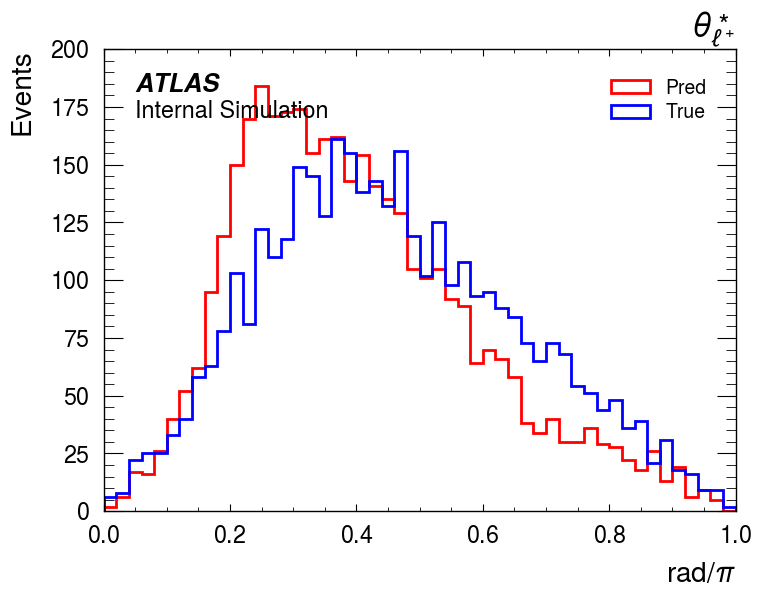

l+ theta RMSE: 0.22347577670068758
Rel err < 20%: 38.83 %


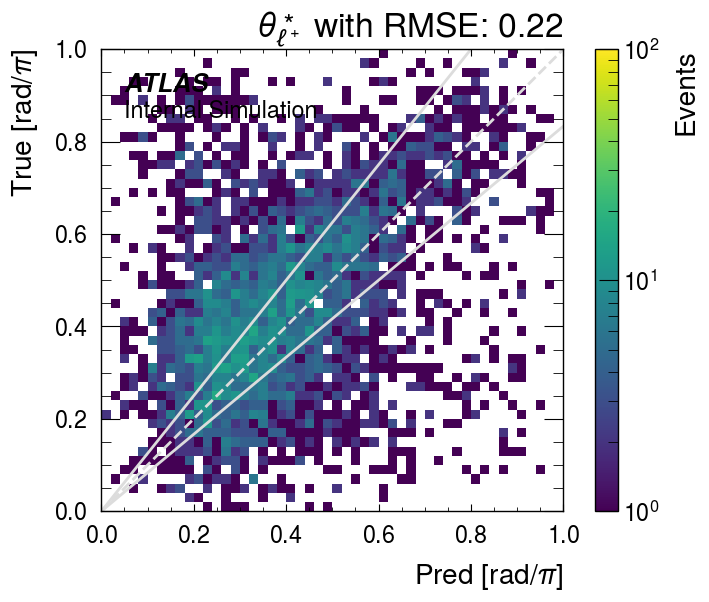

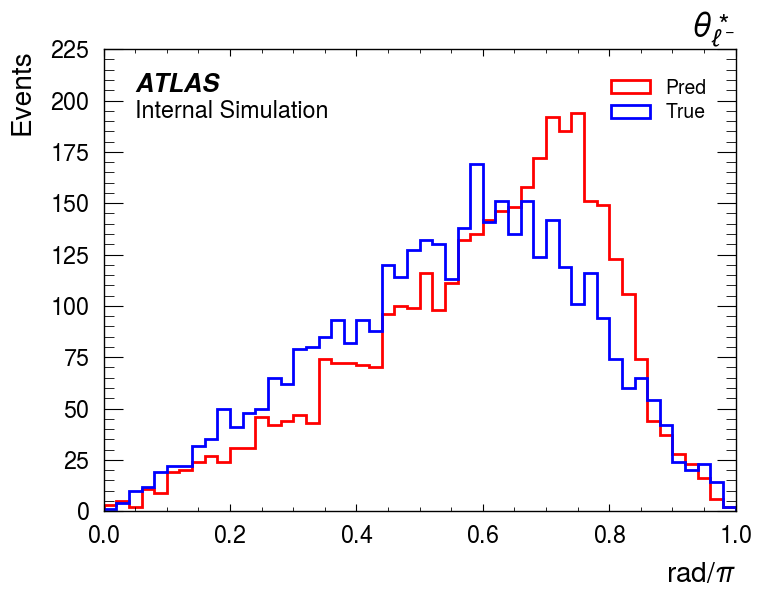

l_ theta RMSE: 0.22347440387944817
Rel err < 20%: 46.66 %


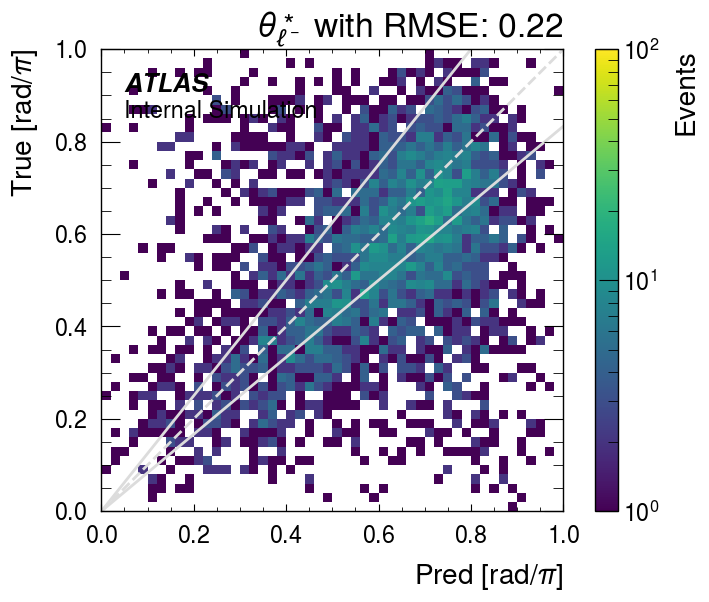

In [ ]:
plot_1d_hist(pred_l0_theta_phi[0], true_l0_theta_phi[0], r"$\theta^\ast_{\ell^+}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
print("l+ theta RMSE:", rmse(pred_l0_theta_phi[0], true_l0_theta_phi[0]))
plot_2d_hist(pred_l0_theta_phi[0], true_l0_theta_phi[0], r"$\theta^\ast_{\ell^+}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)
plot_1d_hist(pred_l1_theta_phi[0], true_l1_theta_phi[0], r"$\theta^\ast_{\ell^-}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
print("l_ theta RMSE:", rmse(pred_l1_theta_phi[0], true_l1_theta_phi[0]))
plot_2d_hist(pred_l1_theta_phi[0], true_l1_theta_phi[0], r"$\theta^\ast_{\ell^-}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)

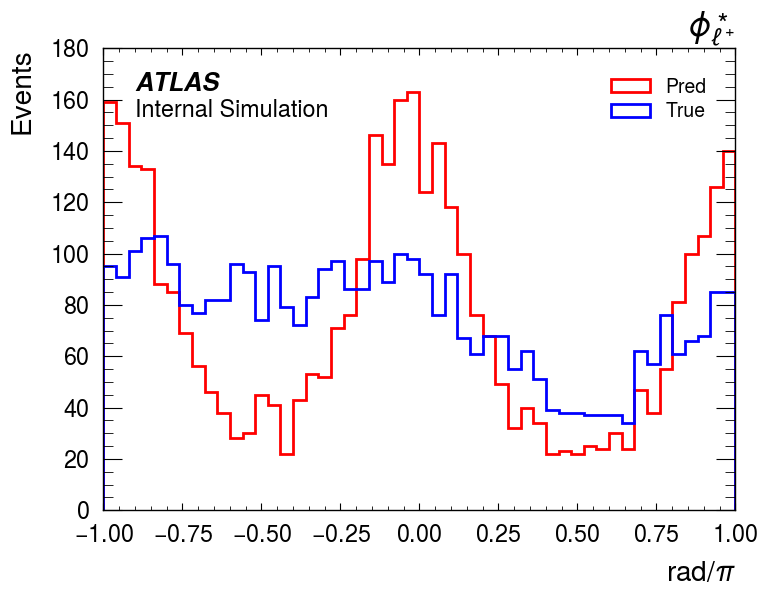

l+ phi RMSE: 0.75155393645179
Rel err < 20%: 20.19 %


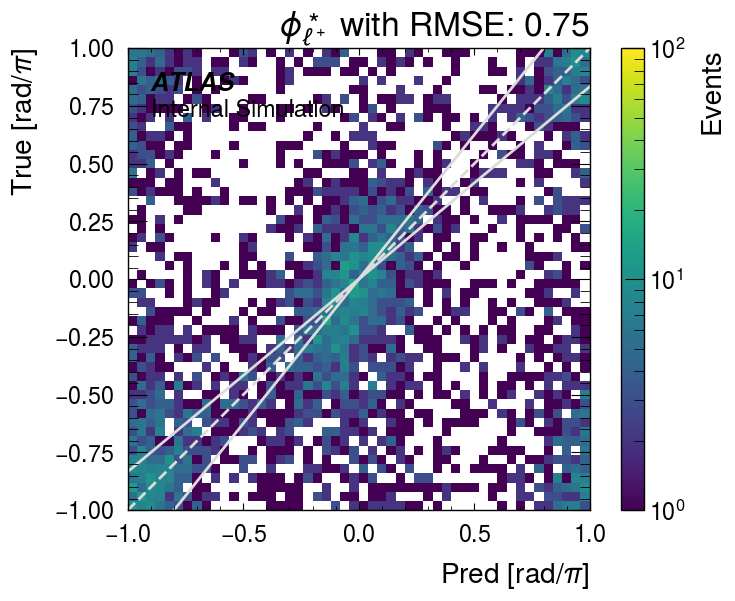

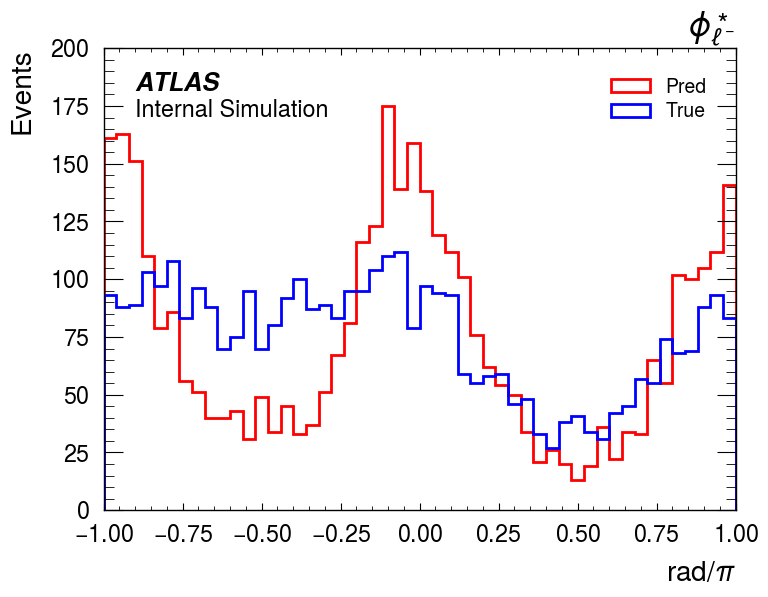

l- phi RMSE: 0.7689594205085317
Rel err < 20%: 18.78 %


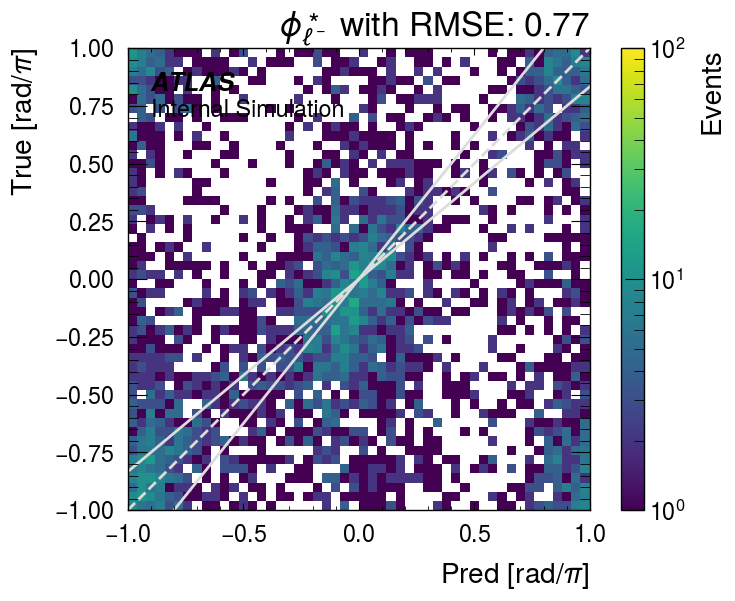

In [ ]:
plot_1d_hist(pred_l0_theta_phi[1], true_l0_theta_phi[1], r"$\phi^\ast_{\ell^+}$", np.linspace(-1, 1, 51), unit="rad/$\pi$")
print("l+ phi RMSE:", rmse(pred_l0_theta_phi[1], true_l0_theta_phi[1]))
plot_2d_hist(pred_l0_theta_phi[1], true_l0_theta_phi[1], r"$\phi^\ast_{\ell^+}$", np.linspace(-1, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)
plot_1d_hist(pred_l1_theta_phi[1], true_l1_theta_phi[1], r"$\phi^\ast_{\ell^-}$", np.linspace(-1, 1, 51), unit="rad/$\pi$")
print("l- phi RMSE:", rmse(pred_l1_theta_phi[1], true_l1_theta_phi[1]))
plot_2d_hist(pred_l1_theta_phi[1], true_l1_theta_phi[1], r"$\phi^\ast_{\ell^-}$", np.linspace(-1, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)

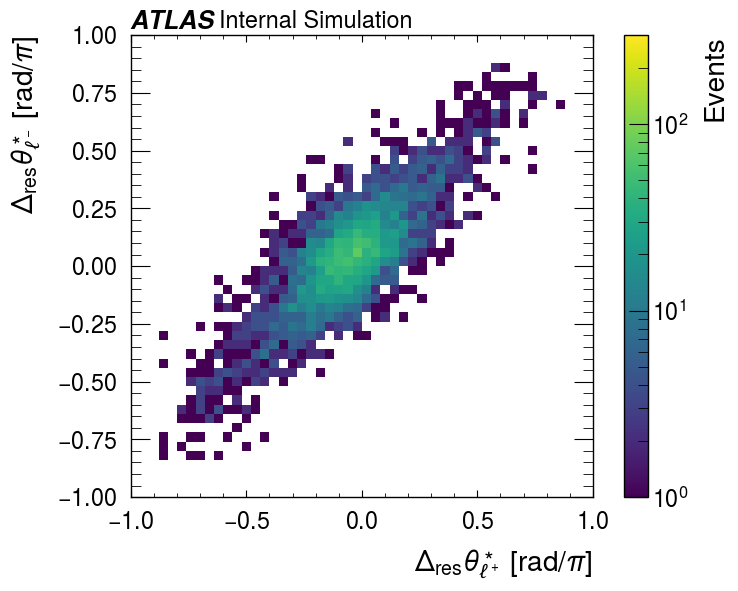

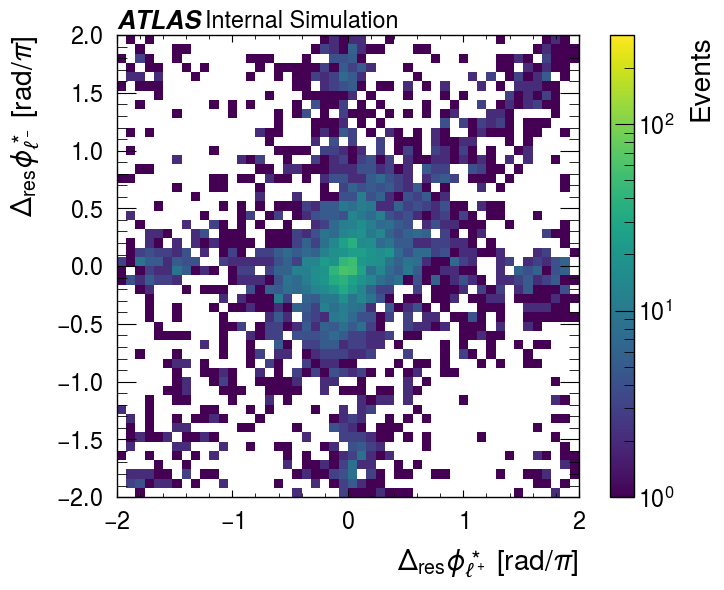

In [ ]:
l0_theta_res = pred_l0_theta_phi[0] - true_l0_theta_phi[0]
l1_theta_res = pred_l1_theta_phi[0] - true_l1_theta_phi[0]
plot_2d_res_hist(l0_theta_res, l1_theta_res, name_pos=r"$\theta^\ast_{\ell^+}$", name_neg=r"$\theta^\ast_{\ell^-}$", bins_edges=np.linspace(-1, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=3e2)

l0_phi_res = pred_l0_theta_phi[1] - true_l0_theta_phi[1]
l1_phi_res = pred_l1_theta_phi[1] - true_l1_theta_phi[1]
plot_2d_res_hist(l0_phi_res, l1_phi_res, name_pos=r"$\phi^\ast_{\ell^+}$", name_neg=r"$\phi^\ast_{\ell^-}$", bins_edges=np.linspace(-2, 2, 51), log=True, unit="rad/$\pi$", color="black", vmax=3e2)

In [ ]:
def dphi(phi1, phi2):
    phi_diff = phi1 * np.pi - phi2 * np.pi
    phi_diff = np.where(phi_diff < 0.0, -phi_diff, phi_diff)
    phi_diff = np.where(phi_diff > 2.0 * np.pi, phi_diff - 2.0 * np.pi, phi_diff)
    phi_diff = np.where(phi_diff >= np.pi, 2.0 * np.pi - phi_diff, phi_diff)
    return np.divide(phi_diff, np.pi)

def dtheta(theta1, theta2):
	theta_diff = theta1 * np.pi - theta2 * np.pi
	theta_diff = np.where(theta_diff < 0.0, -theta_diff, theta_diff)
	theta_diff = np.where(theta_diff > np.pi, theta_diff - np.pi, theta_diff)
	return np.divide(theta_diff, np.pi)

In [ ]:
def plot_1d_true_pred_diff(diff, name, bins_edges=np.linspace(-1, 1, 51), unit="rad/$\pi$", color="black", savepath=None):
	plt.hist(diff, bins=bins_edges, linewidth=2, color="green", histtype="step", label=name)
	plt.legend()
	plt.xlabel(f"{name} [{unit}]", loc="right")
	plt.ylabel("Events", loc="top")
	# plt.title(name, loc="right")
	
	txt = hep.atlas.label("Internal Simulation", data=True, loc=2, rlabel="")
	txt[0].set_color(color)
	txt[1].set_color(color)
	plt.tick_params(axis="both", which="major", pad=10)
	if savepath is not None:
		plt.savefig(savepath, bbox_inches="tight")
	plt.show()

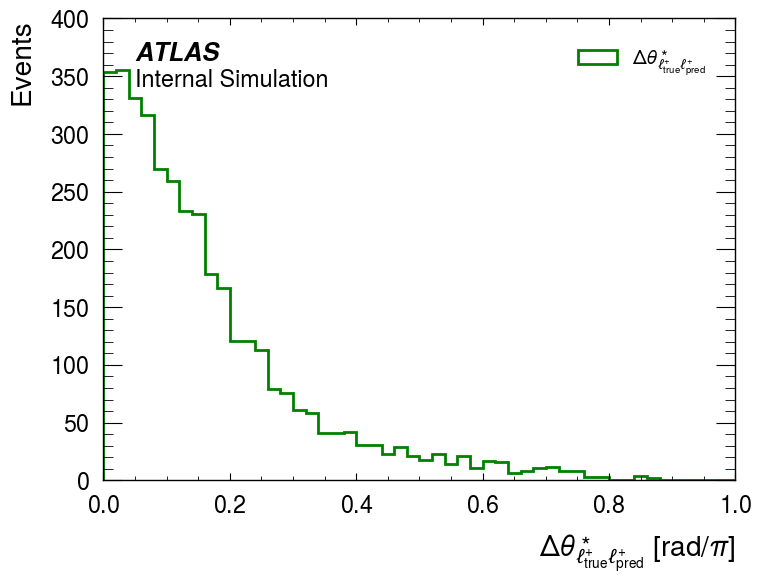

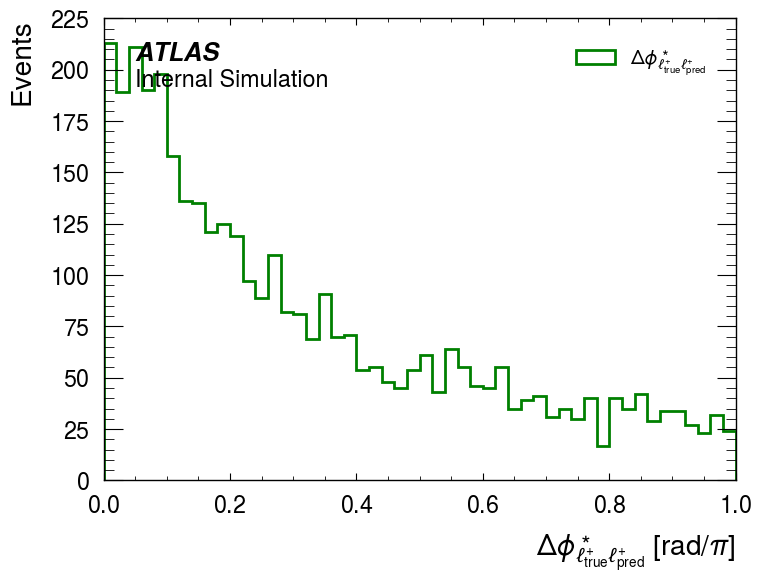

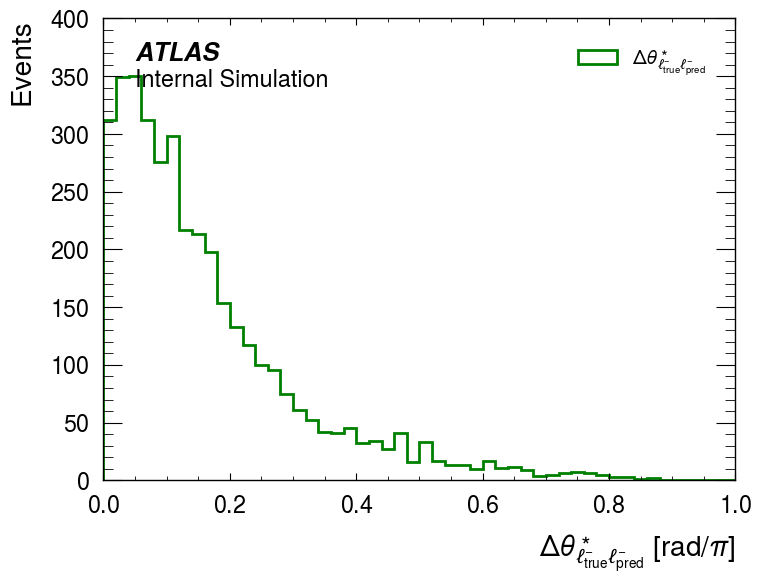

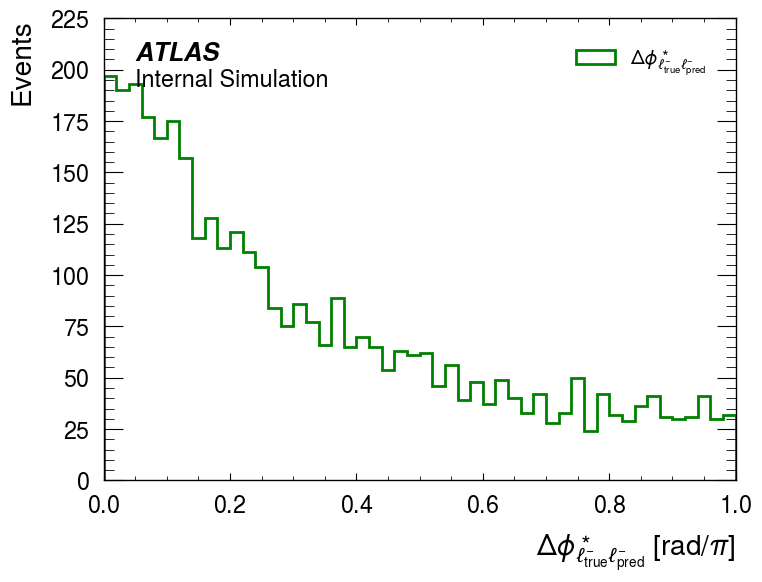

In [ ]:
dtheta_pos = dtheta(pred_l0_theta_phi[0], true_l0_theta_phi[0])
dphi_pos = dphi(pred_l0_theta_phi[1], true_l0_theta_phi[1])
dtheta_neg = dtheta(pred_l1_theta_phi[0], true_l1_theta_phi[0])
dphi_neg = dphi(pred_l1_theta_phi[1], true_l1_theta_phi[1])

plot_1d_true_pred_diff(dtheta_pos, r"$\Delta \theta_{\ell^{+}_\text{true}\ell^{+}_\text{pred}}^\ast$", np.linspace(0, 1, 51), unit="rad/$\pi$")
plot_1d_true_pred_diff(dphi_pos, r"$\Delta \phi_{\ell^{+}_\text{true}\ell^{+}_\text{pred}}^\ast$", np.linspace(0, 1, 51), unit="rad/$\pi$")
plot_1d_true_pred_diff(dtheta_neg, r"$\Delta \theta_{\ell^{-}_\text{true}\ell^{-}_\text{pred}}^\ast$", np.linspace(0, 1, 51), unit="rad/$\pi$")
plot_1d_true_pred_diff(dphi_neg, r"$\Delta \phi_{\ell^{-}_\text{true}\ell^{-}_\text{pred}}^\ast$", np.linspace(0, 1, 51), unit="rad/$\pi$")

In [ ]:
# plot_1d_hist(dtheta(pred_l0_theta_phi[0], pred_l1_theta_phi[0]), dtheta(true_l0_theta_phi[0], true_l1_theta_phi[0]), r"$\Delta \theta_{\ell\ell}^\ast$", np.linspace(0, 0.8, 51), unit="rad/$\pi$", savepath="./figures/dilep/delta_theta.pdf")
# plot_2d_hist(dtheta(pred_l0_theta_phi[0], pred_l1_theta_phi[0]), dtheta(true_l0_theta_phi[0], true_l1_theta_phi[0]), r"$\Delta \theta_{\ell\ell}^\ast$", np.linspace(0, 0.8, 51), log=True, unit="rad/$\pi$", vmax=2e3, savepath="./figures/dilep/delta_theta_2d.pdf")
# plot_1d_hist(dphi(pred_l0_theta_phi[1], pred_l1_theta_phi[1]), dphi(true_l0_theta_phi[1], true_l1_theta_phi[1]), r"$\Delta \phi_{\ell\ell}^\ast$", np.linspace(0, 1, 51), unit="rad/$\pi$", savepath="./figures/dilep/delta_phi.pdf")
# plot_2d_hist(dphi(pred_l0_theta_phi[1], pred_l1_theta_phi[1]), dphi(true_l0_theta_phi[1], true_l1_theta_phi[1]), r"$\Delta \phi_{\ell\ell}^\ast$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=2e3, savepath="./figures/dilep/delta_phi_2d.pdf")

In [ ]:
def plot_1d_swap_hist(pred, truth, pred_swap, true_swap, name, bins_edges=np.linspace(-200, 200, 51), unit="GeV", color="black", savepath=None):
    plt.hist(pred, bins=bins_edges, linewidth=2, color="red", histtype="step", label="Pred")
    plt.hist(truth, bins=bins_edges, linewidth=2, color="blue", histtype="step", label="True")
    plt.hist(pred_swap, bins=bins_edges, linewidth=2, color="tab:orange", histtype="step", label="Pred (tagged)")
    plt.hist(true_swap, bins=bins_edges, linewidth=2, color="tab:blue", histtype="step", label="True (tagged)")
    plt.semilogy()
    plt.legend()
    plt.xlabel(unit, loc="right")
    plt.ylabel("Events", loc="top")
    plt.title(name, loc="right")

    txt = hep.atlas.label("Internal Simulation", data=True, loc=2, rlabel="")
    txt[0].set_color(color)
    txt[1].set_color(color)
    plt.tick_params(axis="both", which="major", pad=10)
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()

def plot_2d_swap_hist(pred, truth, name, bins_edges=np.linspace(-200, 200, 51), log=False, unit="GeV", color="black", vmax=5e3, savepath=None):
    if log:
        norm = LogNorm(vmin=1, vmax=vmax)
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", norm=norm)
    else:
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", vmin=1, vmax=vmax)
    plt.xlabel(f"Pred [{unit}]")
    plt.ylabel(f"True [{unit}]")
    plt.title(f"{name}", loc="right")
    txt = hep.atlas.label("Internal Simulation", data=True, loc=2, rlabel="")
    txt[0].set_color(color)
    txt[1].set_color(color)
    plt.tick_params(axis="both", which="major", pad=10) 
    plt.colorbar(label="Events")
    plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()

In [ ]:
# off-shell := 0 < mW < 50 GeV
# on-shell := 70 GeV < mW < 90 GeV

true_w0_mass = np.sqrt(true_w0_mass_2)
true_w1_mass = np.sqrt(true_w1_mass_2)
pred_w0_mass = np.sqrt(pred_w0_mass_2)
pred_w1_mass = np.sqrt(pred_w1_mass_2)

true_off_w0 = (10 < true_w0_mass) & (true_w0_mass < 50)
true_on_w0 =(70 < true_w0_mass) & (true_w0_mass < 90)
pred_off_w0 = (10 < pred_w0_mass) & (pred_w0_mass < 50)
pred_on_w0 = (70 < pred_w0_mass) & (pred_w0_mass < 90)
pred_correct_w0 = true_off_w0 * pred_off_w0 + true_on_w0 * pred_on_w0
pred_swap_w0 = true_off_w0 * pred_on_w0 + true_on_w0 * pred_off_w0

true_off_w1 = (10 < true_w1_mass) & (true_w1_mass < 50)
true_on_w1 =(70 < true_w1_mass) & (true_w1_mass < 90)
pred_off_w1 = (10 < pred_w1_mass) & (pred_w1_mass < 50)
pred_on_w1 = (70 < pred_w1_mass) & (pred_w1_mass < 90)
pred_correct_w1 = true_off_w1 * pred_off_w1 + true_on_w1 * pred_on_w1
pred_swap_w1 = true_off_w1 * pred_on_w1 + true_on_w1 * pred_off_w1

# # consider both W bosons
# pred_correct = pred_correct_w0 & pred_correct_w1
# pred_swap = pred_swap_w0 | pred_swap_w1

# consider W+ boson only
pred_correct = pred_correct_w0
pred_swap = pred_swap_w0

In [ ]:
# plot_1d_swap_hist(pred_w0_mass, true_w0_mass, pred_w0_mass[pred_swap], true_w0_mass[pred_swap], "$m_{W^+}$ swapped", np.linspace(0, 100, 51))
# plot_2d_swap_hist(pred_w0_mass[pred_swap], true_w0_mass[pred_swap], "$m_{W^+}$ swapped", np.linspace(0, 100, 51), log=True)
# plot_1d_swap_hist(pred_w0_mass, true_w0_mass, pred_w0_mass[pred_correct], true_w0_mass[pred_correct], "$m_{W^+}$ swapped", np.linspace(0, 100, 51))
# plot_2d_swap_hist(pred_w0_mass[pred_correct], true_w0_mass[pred_correct], "$m_{W^+}$ correct", np.linspace(0, 100, 51), log=True)

# plot_1d_swap_hist(pred_w0_px, true_w0_px, pred_w0_px[pred_swap], true_w0_px[pred_swap], "$p^{W^+}_x$ swapped", np.linspace(-200, 200, 51))
# plot_2d_swap_hist(pred_w0_px[pred_swap], true_w0_px[pred_swap], "$p^{W^+}_x$ swapped", np.linspace(-200, 200, 51), log=True)
# plot_1d_swap_hist(pred_w0_pz, true_w0_pz, pred_w0_pz[pred_swap], true_w0_pz[pred_swap], "$p^{W^+}_z$ swapped", np.linspace(-600, 600, 51))
# plot_2d_swap_hist(pred_w0_pz[pred_swap], true_w0_pz[pred_swap], "$p^{W^+}_z$ swapped", np.linspace(-600, 600, 51), log=True)
# plot_1d_swap_hist(pred_w0_energy, true_w0_energy, pred_w0_energy[pred_swap], true_w0_energy[pred_swap], "$E^{W^+}$ swapped", np.linspace(0, 300, 51))
# plot_2d_swap_hist(pred_w0_energy[pred_swap], true_w0_energy[pred_swap], "$E^{W^+}$ swapped", np.linspace(0, 300, 51), log=True, color="black",)

# plot_1d_swap_hist(pred_l0_theta_phi[0], true_l0_theta_phi[0], pred_l0_theta_phi[0][pred_swap], true_l0_theta_phi[0][pred_swap], r"$\theta^\ast_{\ell^+}$ swapped", np.linspace(0, 1, 51), unit="rad/$\pi$")
# plot_2d_swap_hist(pred_l0_theta_phi[0][pred_swap], true_l0_theta_phi[0][pred_swap], r"$\theta^\ast_{\ell^+}$ swapped", np.linspace(0, 1, 51), vmax=1e3, log=True, unit="rad/$\pi$", color="black",)
# plot_1d_swap_hist(pred_l0_theta_phi[1], true_l0_theta_phi[1], pred_l0_theta_phi[1][pred_swap], true_l0_theta_phi[1][pred_swap], r"$\phi^\ast_{\ell^+}$ swapped", np.linspace(-1, 1, 51), unit="rad/$\pi$")
# plot_2d_swap_hist(pred_l0_theta_phi[1][pred_swap], true_l0_theta_phi[1][pred_swap], r"$\phi^\ast_{\ell^+}$ swapped", np.linspace(-1, 1, 51), vmax=1e3, log=True, unit="rad/$\pi$", color="black",)

In [ ]:
# plot_1d_swap_hist(pred_w0_mass, true_w0_mass, pred_w0_mass[pred_correct], true_w0_mass[pred_correct], "$m_{W^+}$ correct", np.linspace(-10, 120, 51))
# plot_2d_swap_hist(pred_w0_mass[pred_correct], true_w0_mass[pred_correct], "$m_{W^+}$ correct", np.linspace(-10, 120, 51), log=True)
# plot_1d_swap_hist(pred_w0_mass, true_w0_mass, pred_w0_mass[pred_correct], true_w0_mass[pred_correct], "$m_{W^+}$ correct", np.linspace(-10, 120, 51))
# plot_2d_swap_hist(pred_w0_mass[pred_correct], true_w0_mass[pred_correct], "$m_{W^+}$ correct", np.linspace(-10, 120, 51), log=True)

# plot_1d_swap_hist(pred_w0_px, true_w0_px, pred_w0_px[pred_correct], true_w0_px[pred_correct], "$p^{W^+}_x$ correct", np.linspace(-200, 200, 51))
# plot_2d_swap_hist(pred_w0_px[pred_correct], true_w0_px[pred_correct], "$p^{W^+}_x$ correct", np.linspace(-200, 200, 51), log=True)
# plot_1d_swap_hist(pred_w0_pz, true_w0_pz, pred_w0_pz[pred_correct], true_w0_pz[pred_correct], "$p^{W^+}_z$ correct", np.linspace(-600, 600, 51))
# plot_2d_swap_hist(pred_w0_pz[pred_correct], true_w0_pz[pred_correct], "$p^{W^+}_z$ correct", np.linspace(-600, 600, 51), log=True)
# plot_1d_swap_hist(pred_w0_energy, true_w0_energy, pred_w0_energy[pred_correct], true_w0_energy[pred_correct], "$E^{W^+}$ correct", np.linspace(0, 300, 51))
# plot_2d_swap_hist(pred_w0_energy[pred_correct], true_w0_energy[pred_correct], "$E^{W^+}$ correct", np.linspace(0, 300, 51), log=True, color="black",)

# plot_1d_swap_hist(pred_l0_theta_phi[0], true_l0_theta_phi[0], pred_l0_theta_phi[0][pred_correct], true_l0_theta_phi[0][pred_correct], r"$\theta^\ast_{\ell^+}$ correct", np.linspace(0, 1, 51), unit="rad/$\pi$")
# plot_2d_swap_hist(pred_l0_theta_phi[0][pred_correct], true_l0_theta_phi[0][pred_correct], r"$\theta^\ast_{\ell^+}$ correct", np.linspace(0, 1, 51), vmax=1e3, log=True, unit="rad/$\pi$", color="black",)
# plot_1d_swap_hist(pred_l0_theta_phi[1], true_l0_theta_phi[1], pred_l0_theta_phi[1][pred_correct], true_l0_theta_phi[1][pred_correct], r"$\phi^\ast_{\ell^+}$ correct", np.linspace(-1, 1, 51), unit="rad/$\pi$")
# plot_2d_swap_hist(pred_l0_theta_phi[1][pred_correct], true_l0_theta_phi[1][pred_correct], r"$\phi^\ast_{\ell^+}$ correct", np.linspace(-1, 1, 51), vmax=1e3, log=True, unit="rad/$\pi$", color="black",)

Found log directories: ['./hww_pctransformer_kfold/fold0/version_0/']


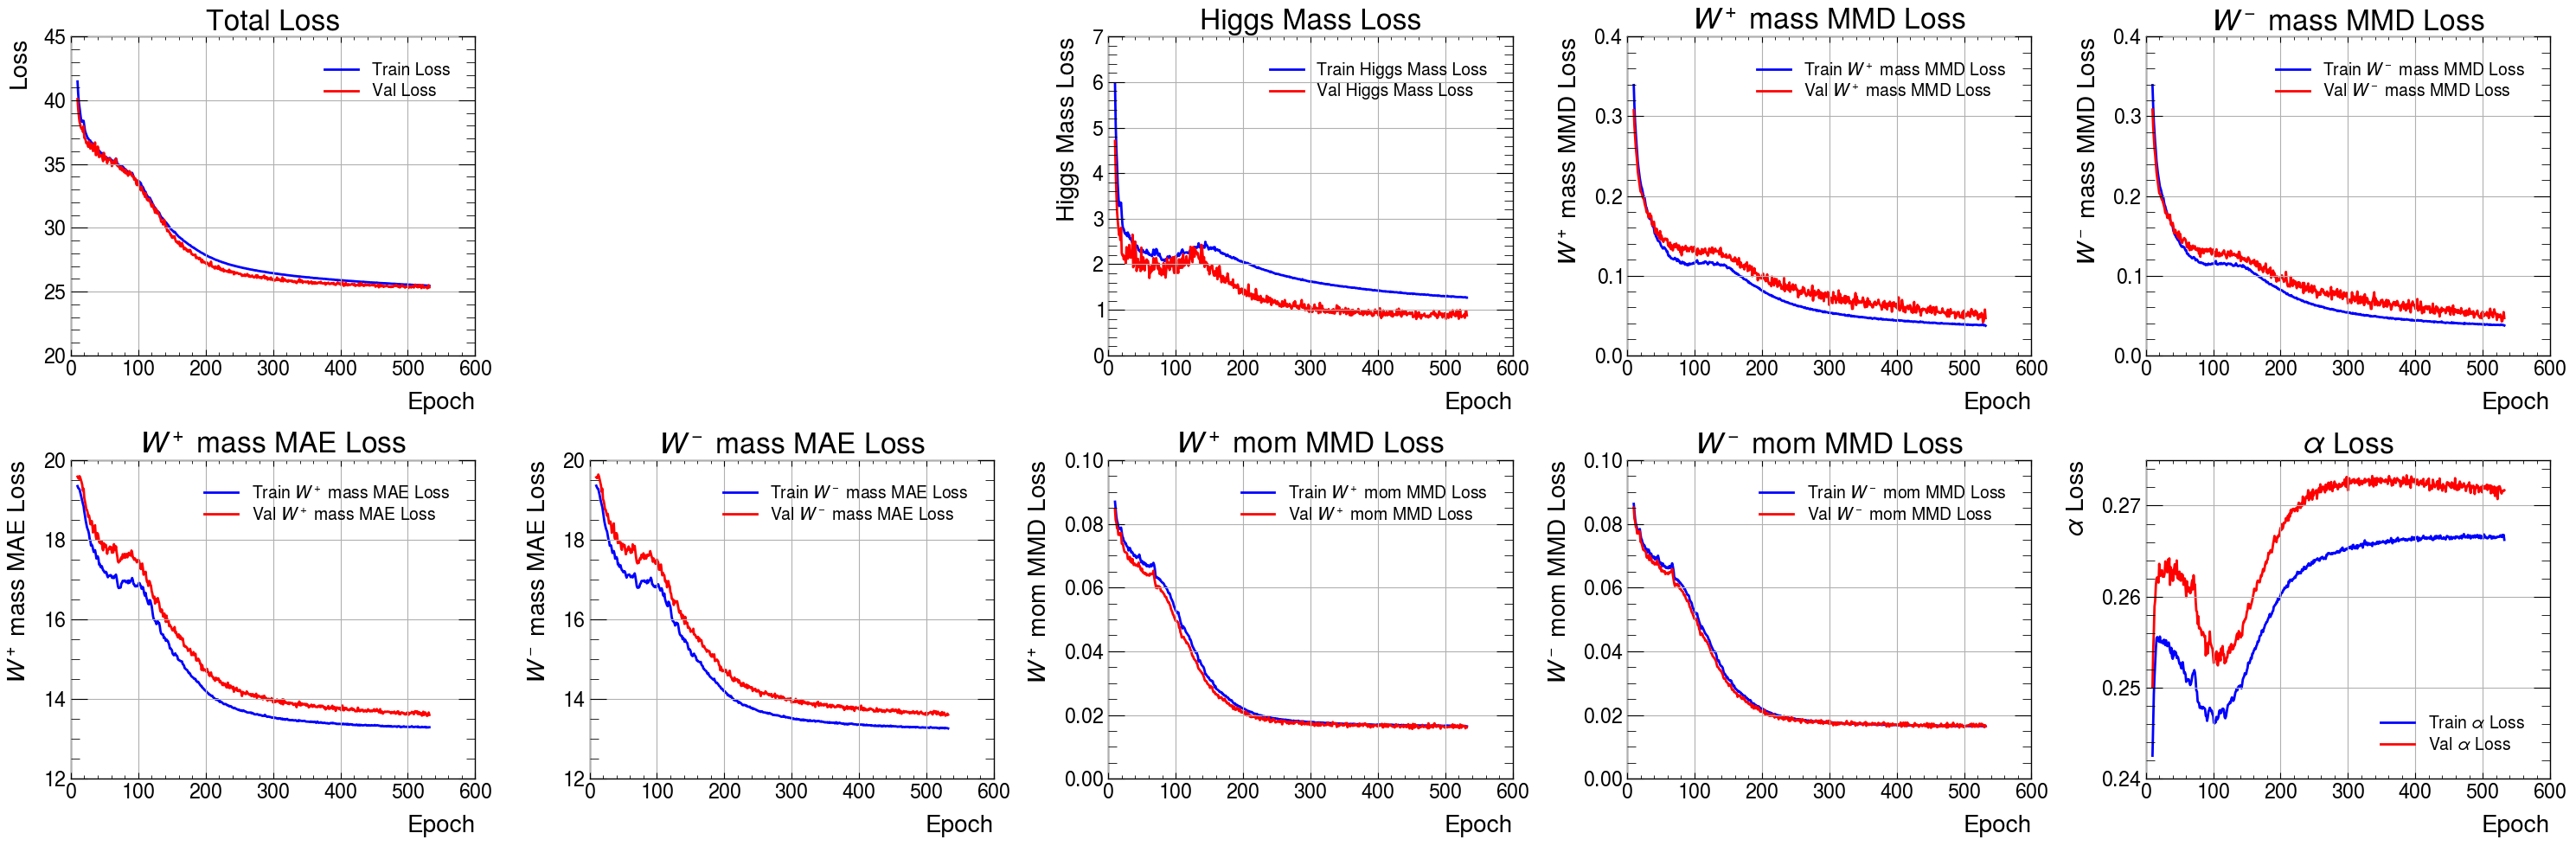

Final Training Losses (Epoch 532):
  Total Loss: 25.451260
  Higgs Mass Loss: 1.266450
  $W^+$ mass MMD Loss: 0.037148
  $W^-$ mass MMD Loss: 0.037474
  $W^+$ mass MAE Loss: 13.293095
  $W^-$ mass MAE Loss: 13.262268
  $W^+$ mom MMD Loss: 0.016436
  $W^-$ mom MMD Loss: 0.016480
  $\alpha$ Loss: 0.266240
Final Validation Losses:
  Total Loss: 25.331352
  Higgs Mass Loss: 0.876605
  $W^+$ mass MMD Loss: 0.046670
  $W^-$ mass MMD Loss: 0.046822
  $W^+$ mass MAE Loss: 13.602831
  $W^-$ mass MAE Loss: 13.607137
  $W^+$ mom MMD Loss: 0.016170
  $W^-$ mom MMD Loss: 0.016471
  $\alpha$ Loss: 0.271682


In [ ]:
log_dirs = glob.glob(f"./hww_pctransformer_kfold/{fold}/*/")
print(f"Found log directories: {log_dirs}")
if not log_dirs:
    print("No logs found.")
else:
    metrics_path = os.path.join(log_dirs[0], "metrics.csv")
    if not os.path.exists(metrics_path):
        print(f"No metrics.csv found in {log_dirs[0]}")
    else:
        df = pd.read_csv(metrics_path)
        df_clean = df.copy()
        df_clean_train = (
            df_clean[df_clean["loss"].notna()] if "loss" in df_clean.columns else pd.DataFrame()
        )
        df_clean_val = (
            df_clean[df_clean["val_loss"].notna()] if "val_loss" in df_clean.columns else pd.DataFrame()
        )

        if df_clean_train.empty or df_clean_val.empty:
            print("Not enough training or validation records to visualize.")
        else:
            fig, axes = plt.subplots(2, 5, figsize=(30, 10))
            axes = axes.flatten()

            plot_configs = [
                ("loss", "val_loss", "Total Loss", "Loss"),
                ("huber_loss", "val_huber_loss", "huber Loss", "Huber"),
                # ("neg_r2_loss", "val_neg_r2_loss", "Negative $R^2$ Loss", "Neg $R^2$ Loss"),
                # ("nu_mass_loss", "val_nu_mass_loss", "Neutrino Mass Loss", "Nu Mass Loss"),
                # ("dinu_pt_loss", "val_dinu_pt_loss", r"$p^{\nu\nu}_T$ Loss", r"$p^{\nu\nu}_T$ Loss"),
                ("higgs_mass_loss", "val_higgs_mass_loss", "Higgs Mass Loss", "Higgs Mass Loss"),
                ("w_mass_mmd0_loss", "val_w_mass_mmd0_loss", "$W^+$ mass MMD Loss", "$W^+$ mass MMD Loss"),
                ("w_mass_mmd1_loss", "val_w_mass_mmd1_loss", "$W^-$ mass MMD Loss", "$W^-$ mass MMD Loss"),
                ("w0_mass_mae_loss", "val_w0_mass_mae_loss", "$W^+$ mass MAE Loss", "$W^+$ mass MAE Loss"),
                ("w1_mass_mae_loss", "val_w1_mass_mae_loss", "$W^-$ mass MAE Loss", "$W^-$ mass MAE Loss"),
                ("aux_mom_mmd0_loss", "val_aux_mom_mmd0_loss", "$W^+$ mom MMD Loss", "$W^+$ mom MMD Loss"),
                ("aux_mom_mmd1_loss", "val_aux_mom_mmd1_loss", "$W^-$ mom MMD Loss", "$W^-$ mom MMD Loss"),
                ("alpha_loss", "val_alpha_loss", r"$\alpha$ Loss", r"$\alpha$ Loss"),
            ]

            def apply_scale(ax, data):
                finite = data.replace([np.inf, -np.inf], np.nan).dropna()
                if finite.empty:
                    return
                if (finite <= 0).any():
                    ax.set_yscale("symlog", linthresh=1e-3)
                else:
                    ax.set_yscale("log")

            epochs_train = df_clean_train["epoch"].iloc[10:]
            epochs_val = df_clean_val["epoch"].iloc[10:]

            for ax, (train_col, val_col, title, ylabel) in zip(axes, plot_configs):
                if train_col not in df_clean_train.columns or val_col not in df_clean_val.columns:
                    ax.set_visible(False)
                    continue

                ax.plot(epochs_train, df_clean_train[train_col].iloc[10:], label=f"Train {ylabel}", color="blue")
                ax.plot(epochs_val, df_clean_val[val_col].iloc[10:], label=f"Val {ylabel}", color="red")
                ax.set_xlabel("Epoch")
                ax.set_ylabel(ylabel)
                ax.set_title(title)
                ax.legend()
                ax.grid(True)
                # apply_scale(ax, pd.concat([df_clean_train[train_col], df_clean_val[val_col]]))

            plt.tight_layout()
            plt.show()

            last_epoch = df_clean_train["epoch"].iloc[-1]
            print(f"Final Training Losses (Epoch {last_epoch}):")
            for train_col, _, title, _ in plot_configs:
                if train_col in df_clean_train.columns:
                    print(f"  {title}: {df_clean_train[train_col].iloc[-1]:.6f}")

            print("Final Validation Losses:")
            for _, val_col, title, _ in plot_configs:
                if val_col in df_clean_val.columns:
                    print(f"  {title}: {df_clean_val[val_col].iloc[-1]:.6f}")

In [ ]:
# import shap
# import matplotlib as mpl

# mpl.rcParams.update(mpl.rcParamsDefault)

# # Use GradientExplainer with separate background and test samples
# background_sample = torch.tensor(train_features[0:256]).float().to(device)
# samples_to_explain = torch.tensor(train_features[512:512+1024]).float().to(device)
# explainer = shap.GradientExplainer(model, background_sample)
# shap_values = explainer.shap_values(samples_to_explain, nsamples=200)

# for i in range(shap_values.shape[-1]):
# 	fig = plt.figure(figsize=(10, 8))
# 	shap.summary_plot(
# 		shap_values[:, :, i],
# 		samples_to_explain.cpu().numpy(),
# 		# No feature_names - will use feature indices 0-71
# 		plot_type="dot",
# 		max_display=10,
# 		show=False,
# 	)
# 	plt.title(f"SHAP Summary Plot for Output {i}", fontsize=16)
# 	plt.tight_layout()
# 	plt.show()

In [ ]:
# Set mh = 125.0 GeV and solve pz of (nu1) W1 (detail please see ./mh_constraint.md)
# Pzv1 and Ev1 are unknowns

mh = 125.0

def A(Ew0, El1):    
    return Ew0 + El1

def B(
        Pxw0, Pxw1, 
        Pyw0, Pyw1,
        Pzl1, Pzw0
    ):
    Pxh = Pxw0 + Pxw1
    Pyh = Pyw0 + Pyw1
    
    return Pxh + Pyh + Pzw0 + Pzl1

def Ptv1(Pxw1, Pxl1, Pyw1, Pyl1): # can be regressed from NN
    Pxv1 = Pxw1 - Pxl1
    Pyv1 = Pyw1 - Pyl1
    return np.sqrt(Pxv1**2 + Pyv1**2)

def C(A, B, Ptv1):
    return 0.25 * (mh**2 + (B**2 - A**2) - Ptv1**2)**2 -A**2 * Ptv1**2



def trunk(A, B, C, Ptv1):
    term = (A**2 * B**2 * (C + A**2 * Ptv1**2) * (C + B**2 * Ptv1**2))
    return B**2 * C + 2 * np.sqrt(term) + A**2 * (C + 2 * B**2 * Ptv1**2)

def Pzv1_sol1(A, B, C, Ptv1):
    term = trunk(A, B, C, Ptv1)
    return - np.sqrt(C**2 / term)

def Pzv1_sol2(A, B, C, Ptv1):
    term = trunk(A, B, C, Ptv1)
    return np.sqrt(C**2 / term)

def Pzv1_sol3(A, B, C, Ptv1):
    term1 = trunk(A, B, C, Ptv1)
    term2 = (A**2 - B**2)**2
    return -np.sqrt(term1 / term2)

def Pzv1_sol4(A, B, C, Ptv1):
    term1 = trunk(A, B, C, Ptv1)
    term2 = (A**2 - B**2)**2
    return np.sqrt(term1 / term2)

In [ ]:
A_values = A(pred_w1_energy, true_lep0_energy)
B_values = B(
	pred_w0_px, pred_w1_px,
	pred_w0_py, pred_w1_py,
	true_lep1_pz, pred_w0_pz
)
Ptv1_values = Ptv1(pred_w1_px, true_lep1_px, pred_w1_py, true_lep1_py)
C_values = C(A_values, B_values, Ptv1_values)


Pzv1_sol1_values = Pzv1_sol1(A_values, B_values, C_values, Ptv1_values)
Pzv1_sol2_values = Pzv1_sol2(A_values, B_values, C_values, Ptv1_values)
Pzv1_sol3_values = Pzv1_sol3(A_values, B_values, C_values, Ptv1_values)
Pzv1_sol4_values = Pzv1_sol4(A_values, B_values, C_values, Ptv1_values)

/tmp/ipykernel_189833/3050176126.py:31: RuntimeWarning: invalid value encountered in sqrt
  return B**2 * C + 2 * np.sqrt(term) + A**2 * (C + 2 * B**2 * Ptv1**2)


Number of events with no valid Pzv1 solution: 1236 out of 3770
Selected Pzv1 shape: (3770,)


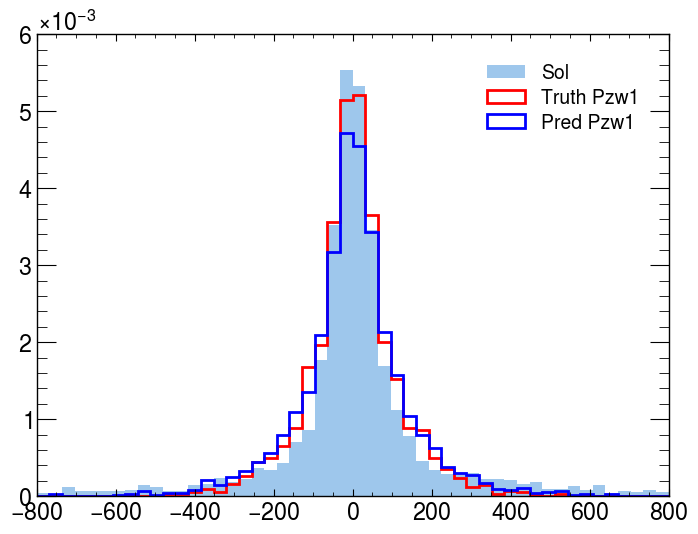

In [ ]:
solutions = np.stack(
    [Pzv1_sol1_values, Pzv1_sol2_values, Pzv1_sol3_values, Pzv1_sol4_values],
    axis=1,
)

rng = np.random.default_rng(42)
selected_pzv1 = np.zeros(Pzv1_sol1_values.shape[0])
zeros_counts = 0
for i, row in enumerate(solutions):
    valid = row[np.isfinite(row)]
    if len(valid) > 0:
        selected_pzv1[i] = rng.choice(valid)
    if len(valid) == 0:
        zeros_counts += 1

print(f"Number of events with no valid Pzv1 solution: {zeros_counts} out of {solutions.shape[0]}")
print("Selected Pzv1 shape:", selected_pzv1.shape)

bins_edges = np.linspace(-800, 800, 51)
plt.hist(selected_pzv1+true_lep1_pz, bins=bins_edges, alpha=0.5, label="Sol", density=True)
plt.hist(pred_w1_pz, bins=bins_edges, histtype="step", linewidth=2, label="Truth Pzw1", density=True, color="red")
plt.hist(true_w1_pz, bins=bins_edges, histtype="step", linewidth=2, label="Pred Pzw1", density=True, color="blue")
plt.legend()
plt.show()

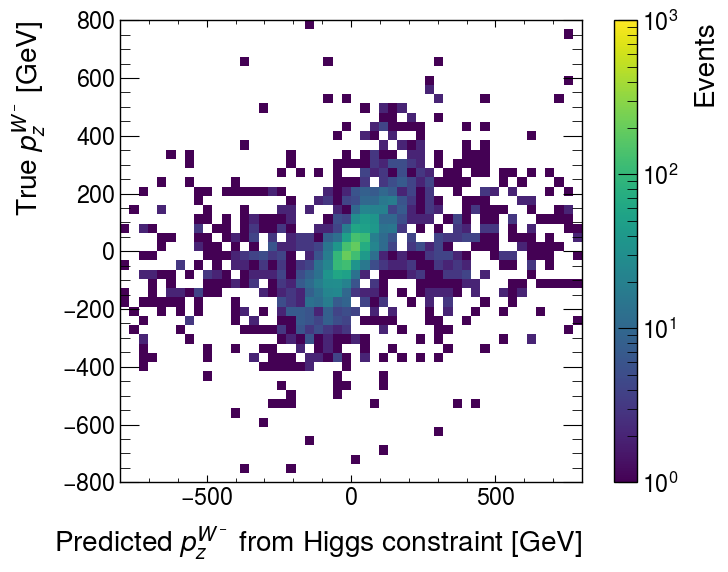

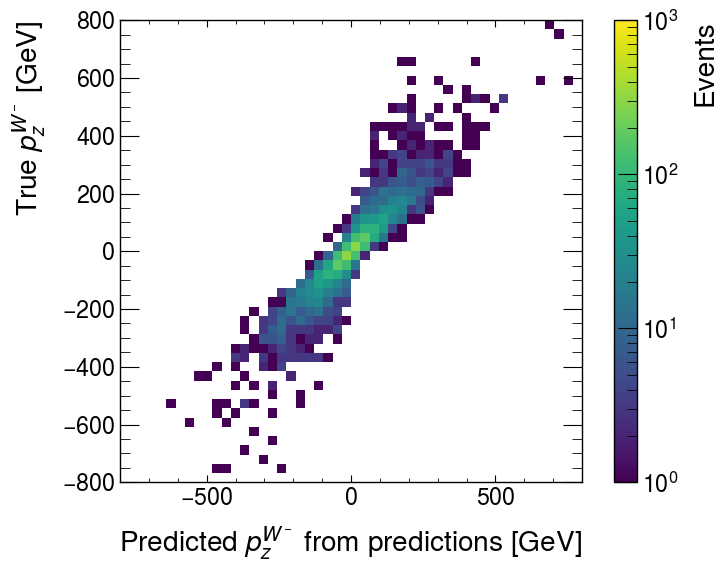

In [ ]:
plt.hist2d(selected_pzv1+true_lep1_pz, true_w1_pz, bins=[bins_edges, bins_edges], cmap="viridis", norm=LogNorm(vmin=1, vmax=1e3))
plt.xlabel("Predicted $p_z^{W^-}$ from Higgs constraint [GeV]")
plt.ylabel("True $p_z^{W^-}$ [GeV]")
plt.colorbar(label="Events")
plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
plt.show()

plt.hist2d(pred_w1_pz, true_w1_pz, bins=[bins_edges, bins_edges], cmap="viridis", norm=LogNorm(vmin=1, vmax=1e3))
plt.xlabel("Predicted $p_z^{W^-}$ from predictions [GeV]")
plt.ylabel("True $p_z^{W^-}$ [GeV]")
plt.colorbar(label="Events")
plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
plt.show()

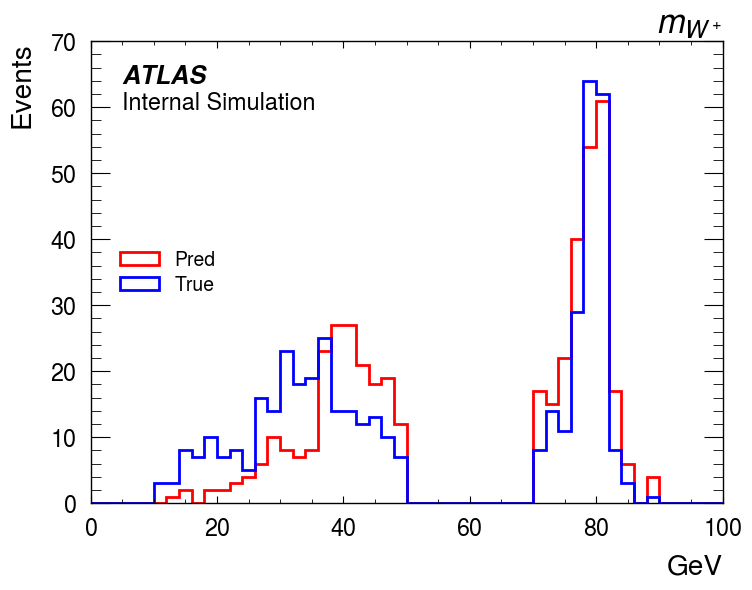

Rel err < 20%: 0.00 %


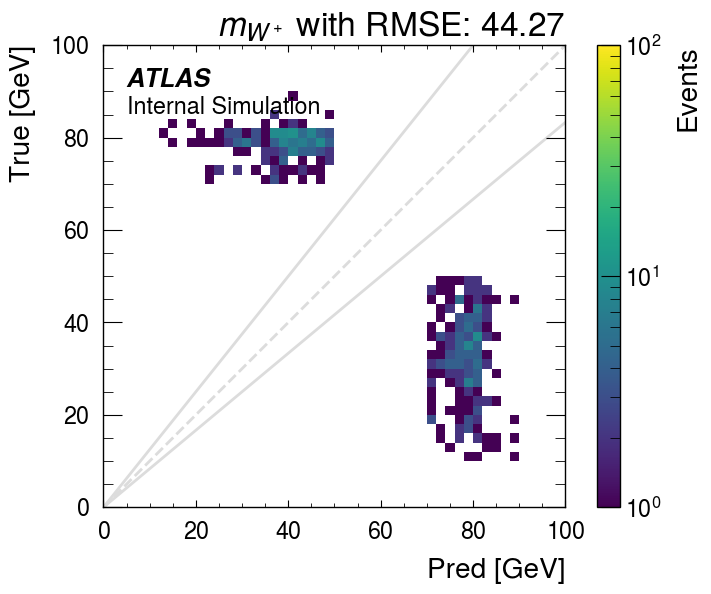

In [ ]:
# off-shell := 0 < mW < 50 GeV
# on-shell := 70 GeV < mW < 90 GeV

true_w0_mass = np.sqrt(true_w0_mass_2)
true_w1_mass = np.sqrt(true_w1_mass_2)
pred_w0_mass = np.sqrt(pred_w0_mass_2)
pred_w1_mass = np.sqrt(pred_w1_mass_2)

true_off_w0 = (10 < true_w0_mass) & (true_w0_mass < 50)
true_on_w0 =(70 < true_w0_mass) & (true_w0_mass < 90)
pred_off_w0 = (10 < pred_w0_mass) & (pred_w0_mass < 50)
pred_on_w0 = (70 < pred_w0_mass) & (pred_w0_mass < 90)
pred_correct_w0 = true_off_w0 * pred_off_w0 + true_on_w0 * pred_on_w0
pred_swap_w0 = true_off_w0 * pred_on_w0 + true_on_w0 * pred_off_w0

true_off_w1 = (10 < true_w1_mass) & (true_w1_mass < 50)
true_on_w1 =(70 < true_w1_mass) & (true_w1_mass < 90)
pred_off_w1 = (10 < pred_w1_mass) & (pred_w1_mass < 50)
pred_on_w1 = (70 < pred_w1_mass) & (pred_w1_mass < 90)
pred_correct_w1 = true_off_w1 * pred_off_w1 + true_on_w1 * pred_on_w1
pred_swap_w1 = true_off_w1 * pred_on_w1 + true_on_w1 * pred_off_w1

# # consider both W bosons
# pred_correct = pred_correct_w0 & pred_correct_w1
# pred_swap = pred_swap_w0 | pred_swap_w1

# consider W+ boson only
pred_correct = pred_correct_w0
pred_swap = pred_swap_w0

bins = np.linspace(0, 100, 51)
plot_1d_hist(np.sqrt(pred_w0_mass_2)[pred_swap], np.sqrt(true_w0_mass_2)[pred_swap], bins_edges=bins, name=r"$m_{W^+}$", unit="GeV")
plot_2d_hist(np.sqrt(pred_w0_mass_2)[pred_swap], np.sqrt(true_w0_mass_2)[pred_swap], name=r"$m_{W^+}$", bins_edges=bins, log=True, unit="GeV")

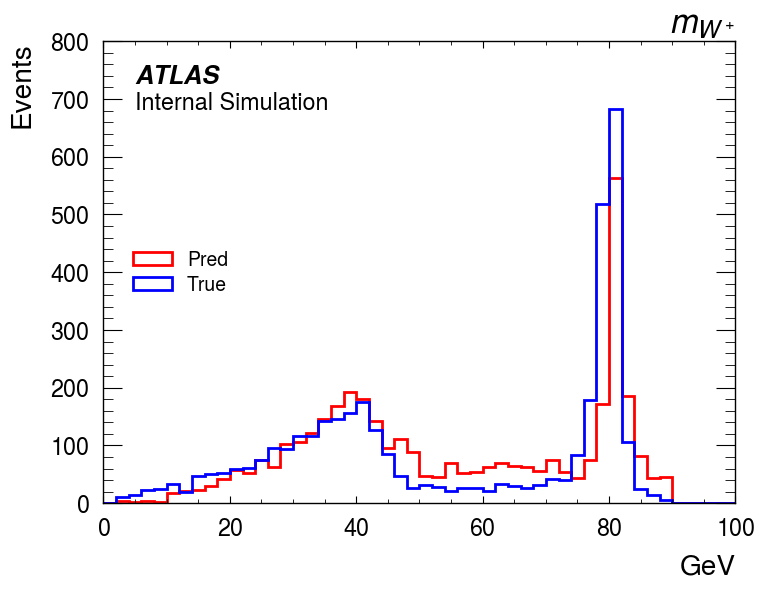

Rel err < 20%: 61.75 %


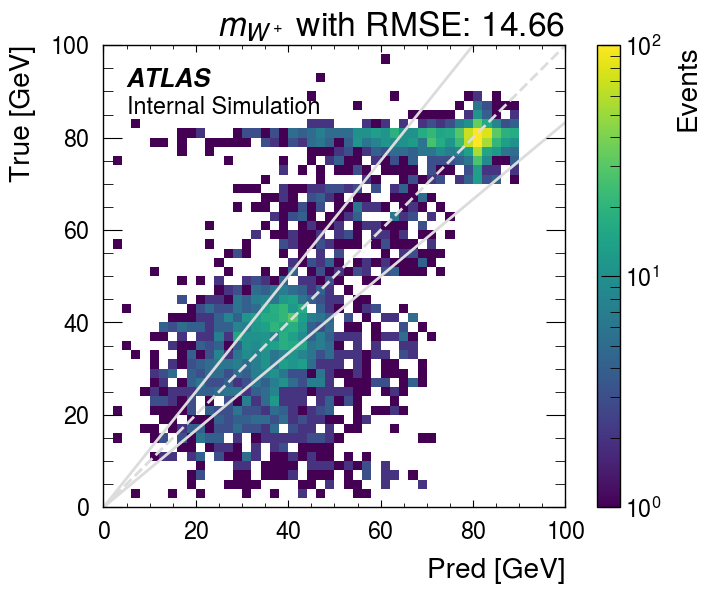

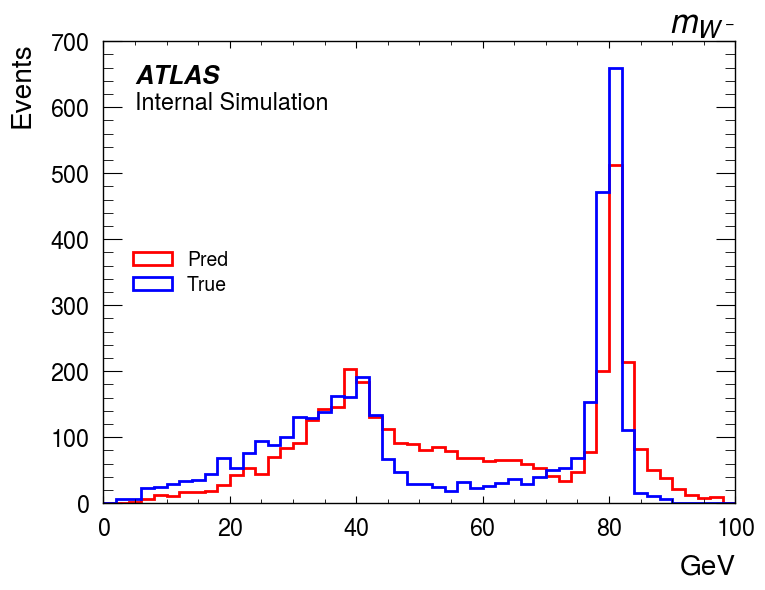

Rel err < 20%: 58.49 %


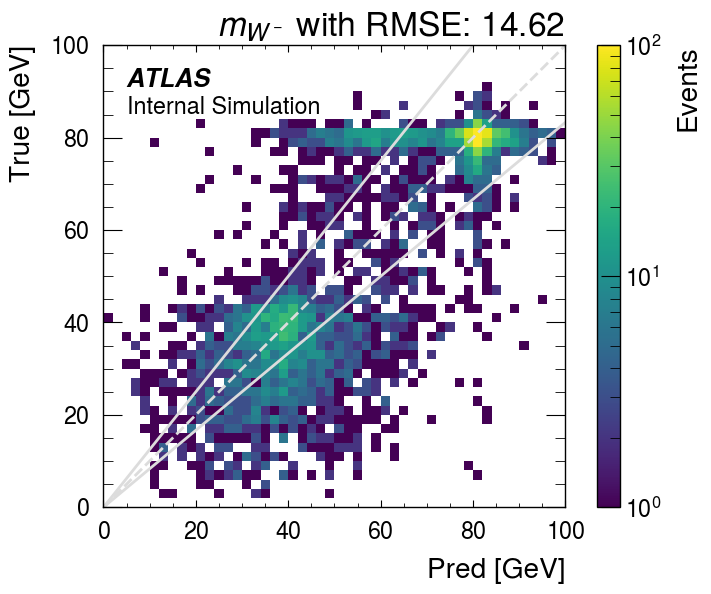

In [ ]:
def replace_lep(w0_p4, w1_p4, lep0_p4, lep1_p4, mask):
    _neu_0_p4 = w0_p4 - lep0_p4
    _neu_1_p4 = w1_p4 - lep1_p4
    # If mask is True, swap the leptons
    new_w0_p4 = np.where(mask[:, None], w0_p4, _neu_1_p4 + lep0_p4)
    new_w1_p4 = np.where(mask[:, None], w1_p4, _neu_0_p4 + lep1_p4)
    return new_w0_p4, new_w1_p4

# swapeed w p4
swap_pred_w0_p4, swap_pred_w1_p4 = replace_lep(
    np.stack([pred_w0_px, pred_w0_py, pred_w0_pz, pred_w0_energy], axis=1),
    np.stack([pred_w1_px, pred_w1_py, pred_w1_pz, pred_w1_energy], axis=1),
    np.stack([true_lep0_px, true_lep0_py, true_lep0_pz, true_lep0_energy], axis=1),
    np.stack([true_lep1_px, true_lep1_py, true_lep1_pz, true_lep1_energy], axis=1),
    pred_correct
)

pred_w0_mass_2_swapped = swap_pred_w0_p4[:, 3]**2 - np.sum(swap_pred_w0_p4[:, :3]**2, axis=1)
pred_w1_mass_2_swapped = swap_pred_w1_p4[:, 3]**2 - np.sum(swap_pred_w1_p4[:, :3]**2, axis=1)

bins = np.linspace(0, 100, 51)
plot_1d_hist(np.sqrt(pred_w0_mass_2_swapped), np.sqrt(true_w0_mass_2), bins_edges=bins, name=r"$m_{W^+}$", unit="GeV")
plot_2d_hist(np.sqrt(pred_w0_mass_2_swapped), np.sqrt(true_w0_mass_2), name=r"$m_{W^+}$", bins_edges=bins, log=True, unit="GeV")
plot_1d_hist(np.sqrt(pred_w1_mass_2_swapped), np.sqrt(true_w1_mass_2), bins_edges=bins, name=r"$m_{W^-}$", unit="GeV")
plot_2d_hist(np.sqrt(pred_w1_mass_2_swapped), np.sqrt(true_w1_mass_2), name=r"$m_{W^-}$", bins_edges=bins, log=True, unit="GeV")

In [ ]:
# manually swap the leptons in the predictions according to the pred_swap mask and see how the distributions change
particles = np.concatenate(
	[
		swap_pred_w0_p4,
		true_l0_p4, # we can measure lepton 4-momentum precisely
		swap_pred_w1_p4,
		true_l1_p4,
	],
	axis=-1,
)
booster = Booster(particles)
booster.setup()
print(particles.shape)
pred_l0_theta_phi_swapped, pred_l1_theta_phi_swapped = booster.lep_theta_phi_in_w_rest()
# pred_xi_pos, pred_xi_neg = booster.lep_xi_in_w_rest()
# pred_cglmp_bij = booster.cglmp_bij()

Make sure the input particles are ordered as [W+, l+, W-, l-]!
Booster setup completed.
(3770, 16)


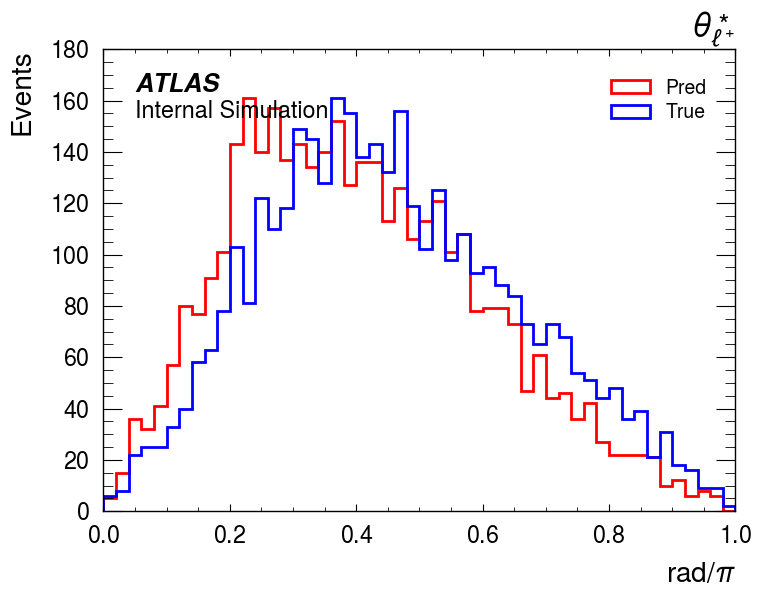

l+ theta RMSE: 0.17906664586084617
Rel err < 20%: 41.41 %


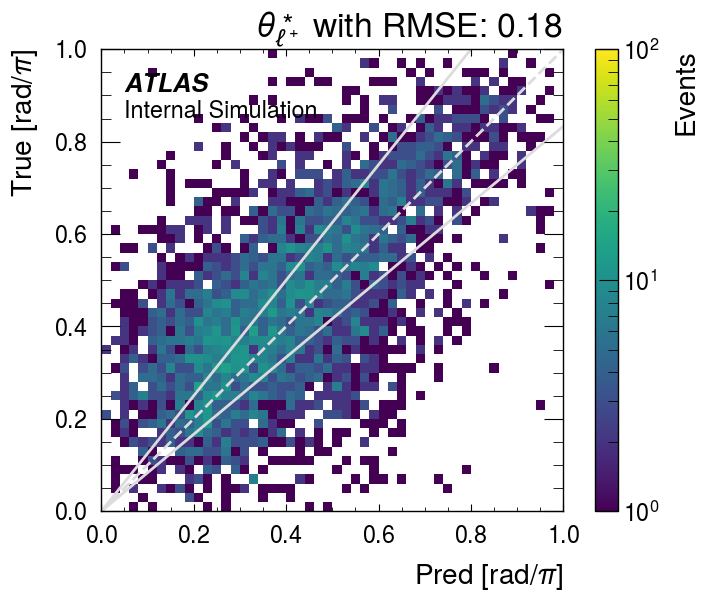

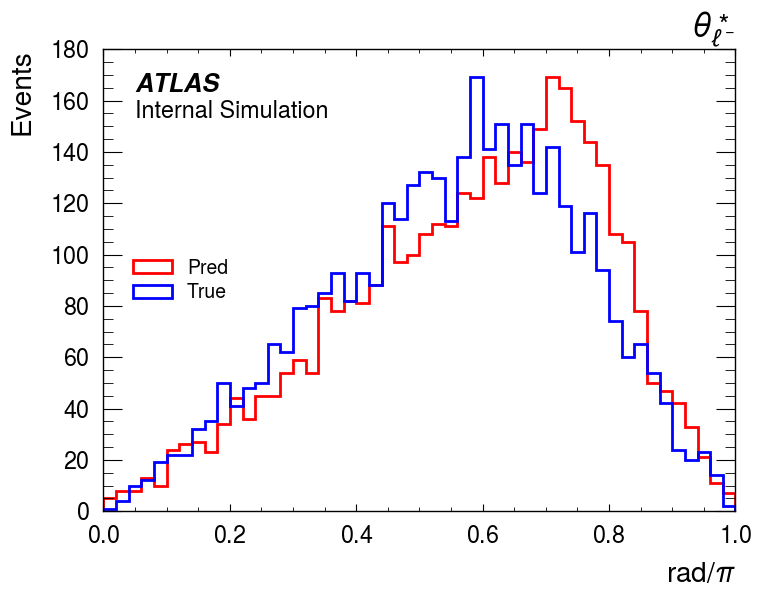

l- theta RMSE: 0.17650665120831982
Rel err < 20%: 51.14 %


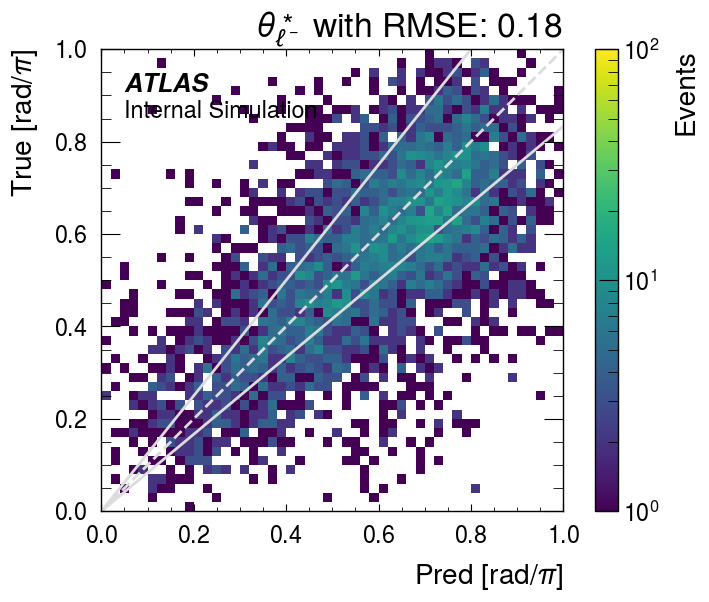

In [ ]:
plot_1d_hist(pred_l0_theta_phi_swapped[0], true_l0_theta_phi[0], r"$\theta^\ast_{\ell^+}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
print("l+ theta RMSE:", rmse(pred_l0_theta_phi_swapped[0], true_l0_theta_phi[0]))
plot_2d_hist(pred_l0_theta_phi_swapped[0], true_l0_theta_phi[0], r"$\theta^\ast_{\ell^+}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)
plot_1d_hist(pred_l1_theta_phi_swapped[0], true_l1_theta_phi[0], r"$\theta^\ast_{\ell^-}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
print("l- theta RMSE:", rmse(pred_l1_theta_phi_swapped[0], true_l1_theta_phi[0]))
plot_2d_hist(pred_l1_theta_phi_swapped[0], true_l1_theta_phi[0], r"$\theta^\ast_{\ell^-}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)

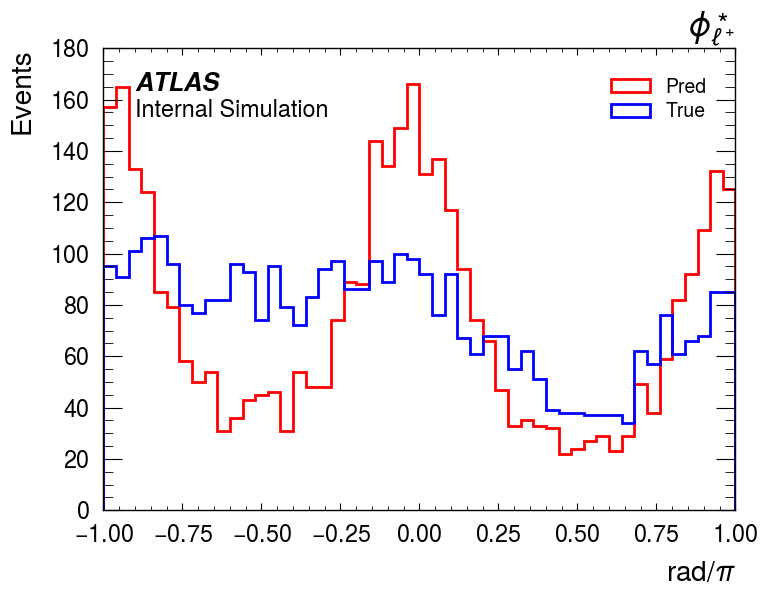

l+ phi RMSE: 0.7467933366193991
Rel err < 20%: 20.32 %


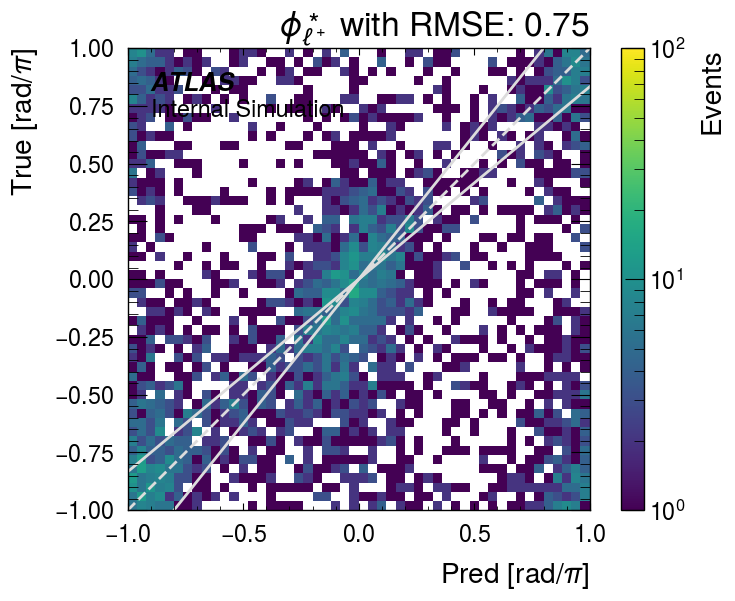

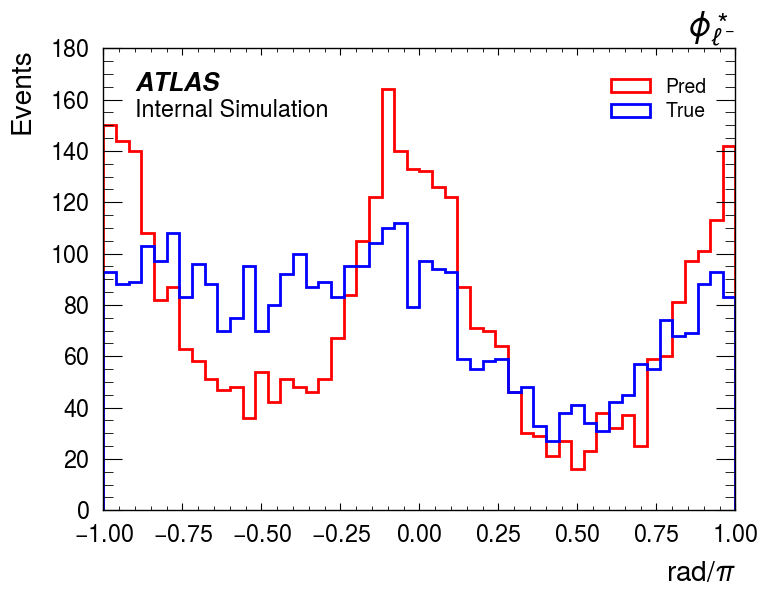

l- phi RMSE: 0.7580496838451388
Rel err < 20%: 20.00 %


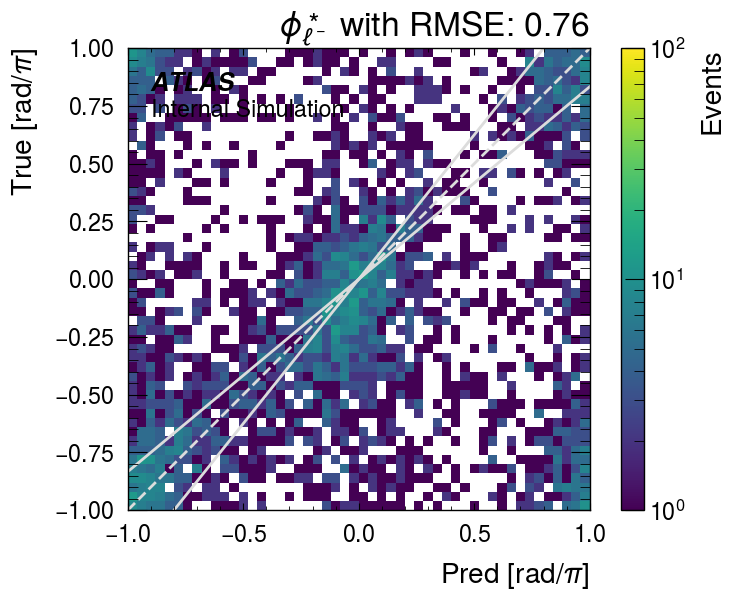

In [ ]:
plot_1d_hist(pred_l0_theta_phi_swapped[1], true_l0_theta_phi[1], r"$\phi^\ast_{\ell^+}$", np.linspace(-1, 1, 51), unit="rad/$\pi$")
print("l+ phi RMSE:", rmse(pred_l0_theta_phi_swapped[1], true_l0_theta_phi[1]))
plot_2d_hist(pred_l0_theta_phi_swapped[1], true_l0_theta_phi[1], r"$\phi^\ast_{\ell^+}$", np.linspace(-1, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)
plot_1d_hist(pred_l1_theta_phi_swapped[1], true_l1_theta_phi[1], r"$\phi^\ast_{\ell^-}$", np.linspace(-1, 1, 51), unit="rad/$\pi$")
print("l- phi RMSE:", rmse(pred_l1_theta_phi_swapped[1], true_l1_theta_phi[1]))
plot_2d_hist(pred_l1_theta_phi_swapped[1], true_l1_theta_phi[1], r"$\phi^\ast_{\ell^-}$", np.linspace(-1, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)